# Visualization Basics

> "The greatest value of a picture is when it forces us to notice what we never expected to see." (John Tukey)

Numbers hide patterns that a picture shows in a second: skew, outliers, clusters, gaps, seasonality, broken data. In ML, plots are how you **find problems before modelling** and **explain results after modelling**.

This chapter covers plotting **directly from pandas**, the **Matplotlib** essentials underneath, **Seaborn** for statistical plots, and the plots every EDA and ML project should have.

**Install** (once, inside your `.venv`):
```
pip install matplotlib seaborn scipy
```

**Contents**
1. Why we plot (Anscombe's quartet)
2. The tools: pandas, Matplotlib, Seaborn
3. Matplotlib anatomy: Figure and Axes
4. Plotting directly from pandas
5. Which chart for which question?
6. Distributions
7. Categories
8. Relationships and correlation
9. Time series
10. Missing values
11. ML plots: target, features, model results
12. Making charts honest and readable
13. Saving figures and a reusable `quick_eda()`
14. Pandas 3.x notes
15. Common mistakes
16. Interview questions
17. Practice questions with solutions
18. Cheat sheet

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# A harmless library-internal notice from seaborn/matplotlib,
# hidden to keep the notebook clean.
warnings.filterwarnings("ignore", message="vert: bool will be deprecated")

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "figure.dpi": 100,
    "figure.figsize": (7, 4),
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("pandas    :", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn   :", sns.__version__)

pandas    : 3.0.6
matplotlib: 3.11.2
seaborn   : 0.13.2


---
# 1. Why we plot: Anscombe's quartet

Four small datasets with **almost identical statistics**: same means, same spread, same correlation, same regression line. Are they the same data?

In [2]:
x123 = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
anscombe = pd.concat([
    pd.DataFrame({"set": "I",   "x": x123, "y": [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]}),
    pd.DataFrame({"set": "II",  "x": x123, "y": [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]}),
    pd.DataFrame({"set": "III", "x": x123, "y": [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]}),
    pd.DataFrame({"set": "IV",  "x": [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],
                  "y": [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]}),
], ignore_index=True)

rows = {}
for name, g in anscombe.groupby("set"):
    slope, intercept = np.polyfit(g["x"], g["y"], 1)
    rows[name] = {"mean_x": g["x"].mean(), "mean_y": g["y"].mean(), "std_y": g["y"].std(),
                  "corr": g["x"].corr(g["y"]), "slope": slope, "intercept": intercept}

pd.DataFrame(rows).T.round(2)

,mean_x,mean_y,std_y,corr,slope,intercept
I,9.0,7.5,2.03,0.82,0.5,3.0
II,9.0,7.5,2.03,0.82,0.5,3.0
III,9.0,7.5,2.03,0.82,0.5,3.0
IV,9.0,7.5,2.03,0.82,0.5,3.0


The statistics are **identical** to two decimals. Now look at them:

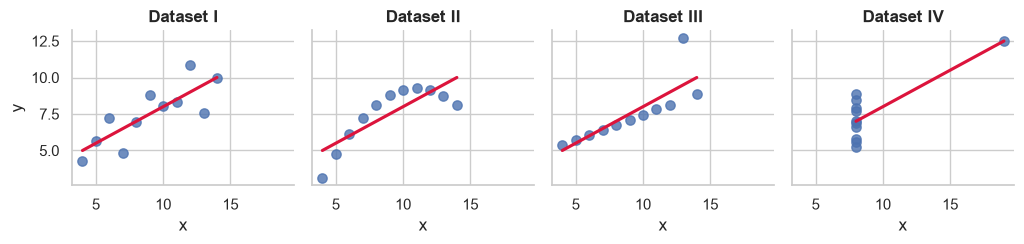

In [3]:
g = sns.lmplot(data=anscombe, x="x", y="y", col="set", col_wrap=4, height=2.6, ci=None,
               scatter_kws={"s": 45}, line_kws={"color": "crimson"})
g.set_titles("Dataset {col_name}")
plt.show()

- **I**: a normal linear relation
- **II**: a clear **curve**, a straight line is the wrong model
- **III**: a perfect line **plus one outlier** that tilts it
- **IV**: no relation at all, one **extreme point** creates the whole correlation

**Lesson:** summary statistics (`describe`, `corr`) can lie. **Always plot your data** before trusting numbers or fitting a model.

---
# 2. The tools: pandas, Matplotlib, Seaborn

| Tool | What it is | Use it for |
|---|---|---|
| **Matplotlib** | the base library, full control of every element | customising anything, multi-panel figures |
| **pandas `.plot`** | a thin wrapper over Matplotlib on Series/DataFrame | **quick** plots straight from your table |
| **Seaborn** | statistical plots on top of Matplotlib, works on **long/tidy** DataFrames (`data=df, x=..., y=..., hue=...`) | distributions, group comparisons, heatmaps, regression |
| Plotly / Altair | interactive charts | dashboards, web apps (not covered here) |

They work **together**: Seaborn and pandas both draw onto Matplotlib `Axes`, so you can mix them and fine-tune with Matplotlib.

Seaborn likes **long format** (chapter 12): one row per observation, one column per variable. That is why `melt` matters for plotting.

## Our datasets

In [4]:
# 1) Students: a typical tabular ML dataset (target: score / passed)
rng = np.random.default_rng(42)
n = 300

hours = rng.gamma(shape=4, scale=1.3, size=n).clip(0.5, 12).round(1)        # right-skewed on purpose
attendance = rng.normal(78, 12, n).clip(35, 100).round(0)
prev_score = rng.normal(62, 14, n).clip(10, 100).round(0)
internet = rng.choice(["Yes", "No"], n, p=[0.8, 0.2])
city = rng.choice(["Indore", "Bhopal", "Delhi", "Pune"], n, p=[0.4, 0.25, 0.2, 0.15])
score = (12 + 5 * hours + 0.25 * attendance + 0.2 * prev_score + 4 * (internet == "Yes") + rng.normal(0, 6, n)).clip(0, 100).round(0)

students = pd.DataFrame({
    "city": city, "hours": hours, "attendance": attendance, "prev_score": prev_score,
    "internet": internet, "score": score,
})
students["passed"] = np.where(students["score"] >= 60, "Yes", "No")
students.loc[rng.choice(n, 30, replace=False), "attendance"] = np.nan       # missing values
students.loc[rng.choice(n, 18, replace=False), "prev_score"] = np.nan

students.head()

,city,hours,attendance,prev_score,internet,score,passed
0,Indore,5.6,73.0,56.0,No,64.0,Yes
1,Indore,6.9,58.0,63.0,Yes,82.0,Yes
2,Indore,5.1,63.0,58.0,Yes,76.0,Yes
3,Indore,4.7,73.0,77.0,Yes,80.0,Yes
4,Bhopal,7.3,72.0,53.0,Yes,72.0,Yes


In [5]:
# 2) Daily demand for 2.5 years (the same kind of series as chapter 13)
rng = np.random.default_rng(13)
idx = pd.date_range("2024-01-01", "2026-06-30", freq="D")
t = np.arange(len(idx))
HOLIDAYS = pd.to_datetime([f"{y}-{md}" for y in (2024, 2025, 2026) for md in ("01-26", "08-15", "10-02")])

daily = pd.Series(
    (200 + 0.06 * t + np.where(idx.dayofweek >= 5, 40, 0) + 25 * np.sin(2 * np.pi * idx.dayofyear / 365.25)
     + np.where(idx.isin(HOLIDAYS), -50, 0) + rng.normal(0, 12, len(idx))).round(0),
    index=idx, name="demand",
)
print(daily.shape)
daily.head(3)

(912,)


2024-01-01    222.0
2024-01-02    164.0
2024-01-03    213.0
Freq: D, Name: demand, dtype: float64

---
# 3. Matplotlib anatomy: Figure and Axes

```
 Figure  (the whole canvas/window)
 └── Axes  (one plot: the area with the data, axes lines, title, labels, legend)
      ├── Axis (x) with ticks and labels
      └── Axis (y)
```

Two styles exist:
- **pyplot style**: `plt.plot(...)`, `plt.title(...)` (implicit "current" plot). Quick but gets confusing with several plots.
- **Object-oriented style** (recommended): `fig, ax = plt.subplots()` then call methods on `ax`. Always clear which plot you are changing.

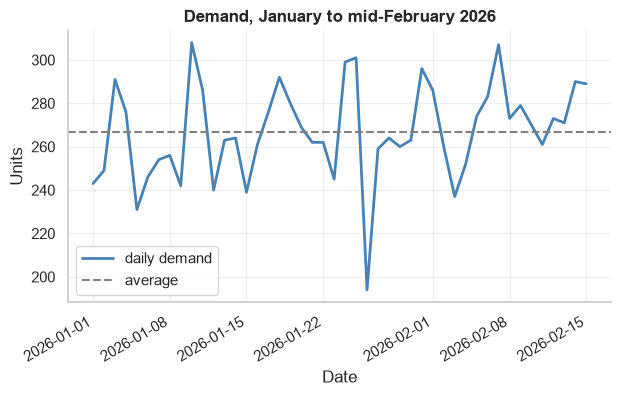

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))                 # one Figure with one Axes

ax.plot(daily["2026-01-01":"2026-02-15"].index, daily["2026-01-01":"2026-02-15"], color="steelblue", linewidth=2, label="daily demand")
ax.axhline(daily["2026-01-01":"2026-02-15"].mean(), color="gray", linestyle="--", label="average")

ax.set_title("Demand, January to mid-February 2026")
ax.set_xlabel("Date")
ax.set_ylabel("Units")
ax.legend()
ax.grid(alpha=0.3)
fig.autofmt_xdate()                                    # rotate the date labels so they do not overlap

plt.show()

## Several plots in one figure

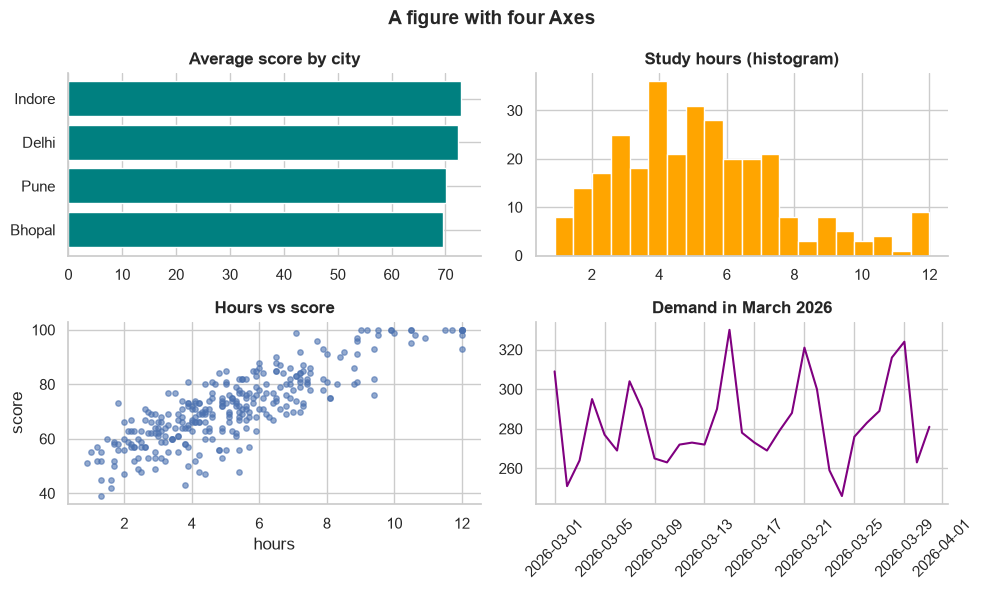

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))        # a 2x2 grid; axes is a 2D array of Axes

city_mean = students.groupby("city")["score"].mean().sort_values()
axes[0, 0].barh(city_mean.index, city_mean.values, color="teal")
axes[0, 0].set_title("Average score by city")

axes[0, 1].hist(students["hours"], bins=20, color="orange", edgecolor="white")
axes[0, 1].set_title("Study hours (histogram)")

axes[1, 0].scatter(students["hours"], students["score"], s=15, alpha=0.6)
axes[1, 0].set_title("Hours vs score")
axes[1, 0].set_xlabel("hours"); axes[1, 0].set_ylabel("score")

axes[1, 1].plot(daily["2026-03-01":"2026-03-31"], color="purple")
axes[1, 1].set_title("Demand in March 2026")
axes[1, 1].tick_params(axis="x", rotation=45)

fig.suptitle("A figure with four Axes", fontsize=14, fontweight="bold")
fig.tight_layout()                                     # fix overlapping labels
plt.show()

Essential Matplotlib calls:

| Goal | Call |
|---|---|
| Title, axis labels | `ax.set_title()`, `ax.set_xlabel()`, `ax.set_ylabel()` |
| Limits | `ax.set_xlim(a, b)`, `ax.set_ylim(a, b)` |
| Log scale | `ax.set_yscale("log")` |
| Legend | `ax.legend()` (needs `label=` in the plot calls) |
| Reference lines | `ax.axhline(y)`, `ax.axvline(x)`, `ax.axvspan(x1, x2)` |
| Text/arrows | `ax.annotate("text", xy=(x, y), xytext=(x2, y2), arrowprops=dict(arrowstyle="->"))` |
| Tick format | `ax.tick_params(axis="x", rotation=45)` |
| Share axes | `plt.subplots(2, 1, sharex=True)` |
| Layout | `fig.tight_layout()` |
| Save | `fig.savefig("name.png", dpi=200, bbox_inches="tight")` |

---
# 4. Plotting directly from pandas

`Series.plot()` and `DataFrame.plot()` give a chart in one line. They return a Matplotlib `Axes`, so you can keep customising.

```python
df.plot(kind="line")   # same as df.plot.line()
```

| `kind` | Chart |
|---|---|
| `line` (default) | trend over an ordered index |
| `bar`, `barh` | compare categories |
| `hist` | distribution of one numeric column |
| `box` | spread and outliers |
| `kde` | smooth distribution curve (needs `scipy`) |
| `scatter` | two numeric columns (`x=`, `y=`) |
| `area` | stacked totals over time |
| `pie` | parts of a whole (use rarely) |

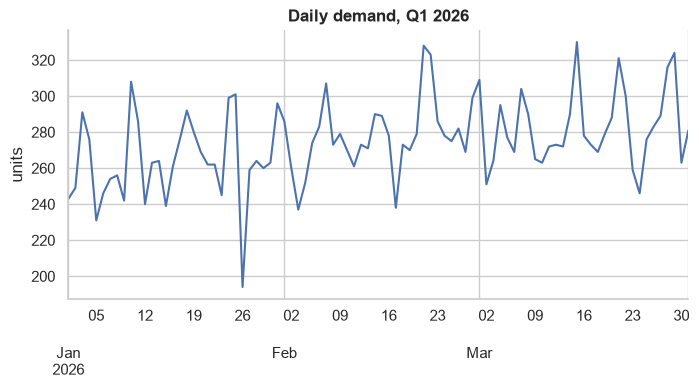

In [8]:
# Line: a datetime index plots against time automatically
daily["2026-01-01":"2026-03-31"].plot(title="Daily demand, Q1 2026", ylabel="units", figsize=(8, 3.5))
plt.show()

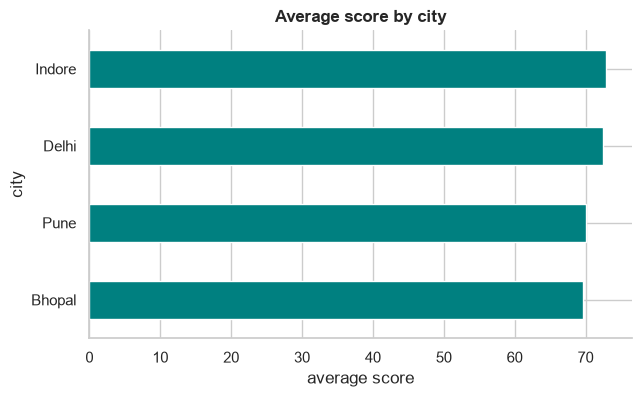

In [9]:
# Bar: a groupby result is already the right shape
students.groupby("city")["score"].mean().sort_values().plot.barh(color="teal", title="Average score by city")
plt.xlabel("average score")
plt.show()

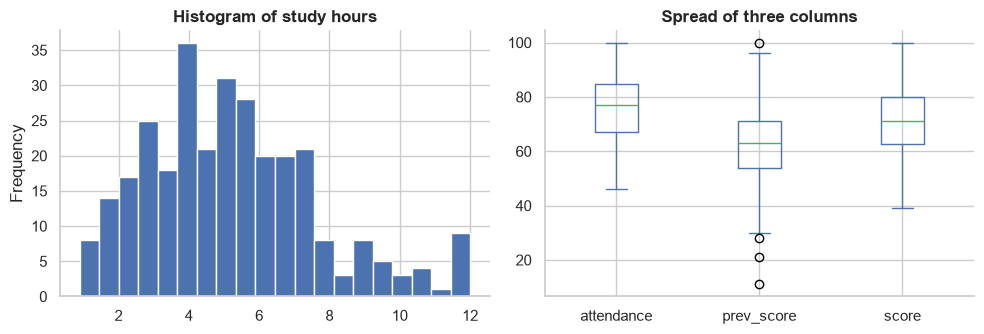

In [10]:
# Histogram and box
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
students["hours"].plot.hist(bins=20, ax=axes[0], edgecolor="white", title="Histogram of study hours")
students[["attendance", "prev_score", "score"]].plot.box(ax=axes[1], title="Spread of three columns")
plt.tight_layout()
plt.show()

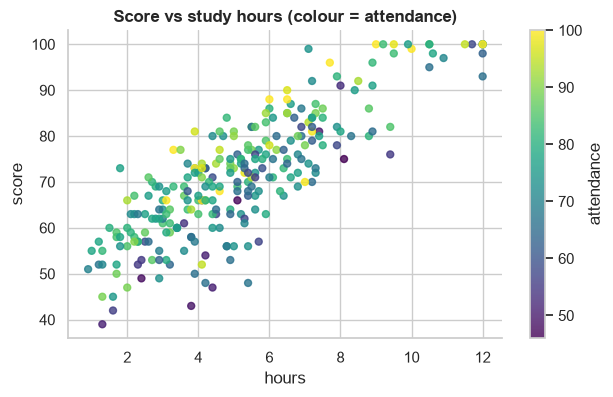

In [11]:
# Scatter: colour by a third numeric column
students.plot.scatter(x="hours", y="score", c="attendance", cmap="viridis", s=25, alpha=0.8, figsize=(7, 4),
                      title="Score vs study hours (colour = attendance)")
plt.show()

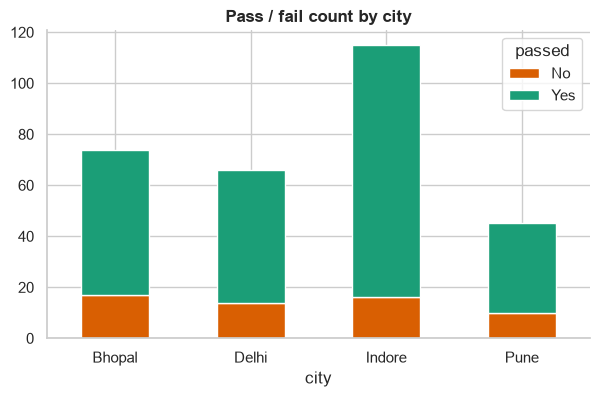

In [12]:
# Stacked bar from a crosstab (chapter 12)
pd.crosstab(students["city"], students["passed"]).plot.bar(stacked=True, color=["#d95f02", "#1b9e77"], figsize=(7, 4),
                                                           title="Pass / fail count by city")
plt.xticks(rotation=0)
plt.show()

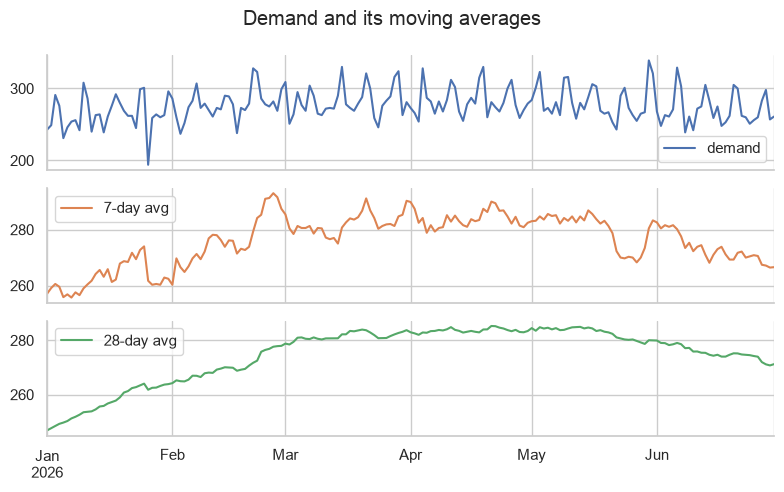

In [13]:
# Several series with subplots=True: one small chart each, same time axis
pd.DataFrame({
    "demand": daily,
    "7-day avg": daily.rolling(7).mean(),
    "28-day avg": daily.rolling(28).mean(),
})["2026-01-01":].plot(subplots=True, figsize=(8, 5), sharex=True, title="Demand and its moving averages")
plt.tight_layout()
plt.show()

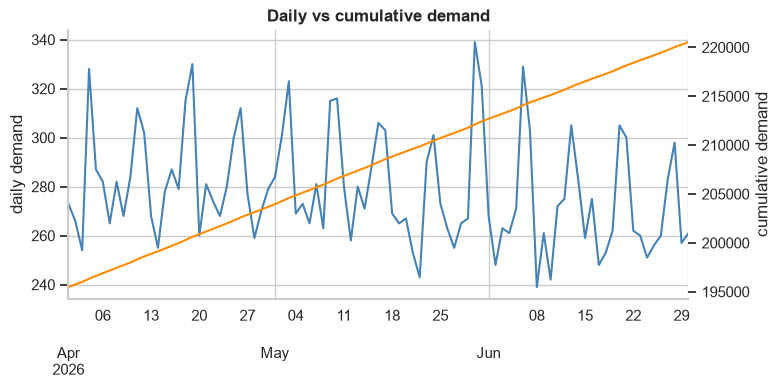

In [14]:
# Two different scales on the same chart (secondary_y). Use sparingly: it is easy to mislead.
pair = pd.DataFrame({"demand": daily, "cumulative": daily.cumsum()})["2026-04-01":]
ax = pair["demand"].plot(color="steelblue", figsize=(8, 3.5), ylabel="daily demand")
pair["cumulative"].plot(secondary_y=True, color="darkorange", ax=ax)
ax.right_ax.set_ylabel("cumulative demand")
plt.title("Daily vs cumulative demand")
plt.show()

**Which to use?** pandas `.plot` for a quick look at a Series/DataFrame. Seaborn when you need **grouping** (`hue`, `col`), confidence intervals, or statistical plots. Matplotlib methods on the returned `ax` for the final touches.

# 5. Which chart for which question?

| Your question | Chart | Notes |
|---|---|---|
| How is **one numeric** variable distributed? | histogram, KDE, box/violin, ECDF | check skew and outliers |
| Compare a number **between groups** | box/violin, bar of mean (with error bar) | prefer box/violin when the spread matters |
| **How many** per category? | bar chart (sorted) | horizontal when labels are long |
| **Share of total** | stacked/100% bar | pie only for 2-4 slices |
| Relation of **two numeric** variables | scatter (+ trend line) | alpha / hexbin for many points |
| Relations of **many numeric** variables | correlation heatmap, pairplot | |
| **Trend over time** | line | add rolling mean for noisy data |
| **Pattern by two categories** (weekday x month) | heatmap | pivot first |
| **Missing** data | heatmap of `isna()`, bar of percentages | |
| Classifier results | confusion matrix heatmap | |
| Regression results | predicted vs actual, residual plot | |

---
# 6. Distributions

First question for any numeric column: **what does it look like?** (centre, spread, skew, outliers, multiple peaks)

## 6.1 Histogram and KDE

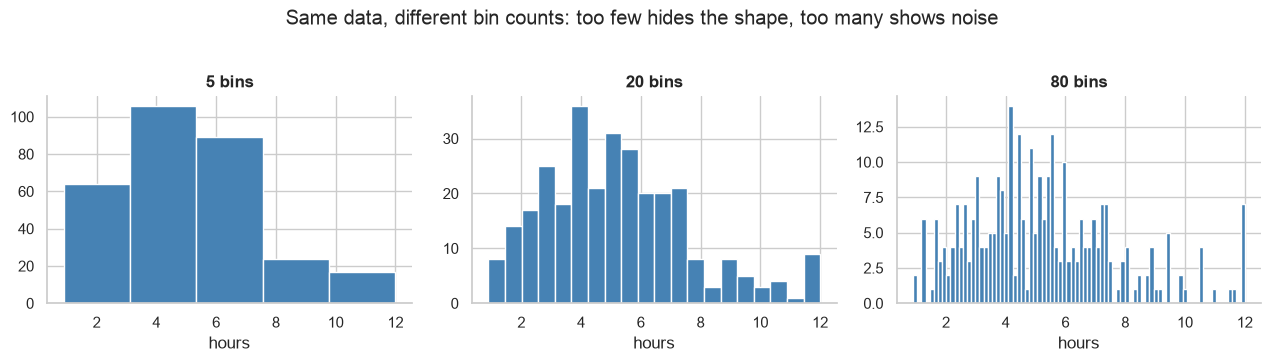

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

for ax, bins in zip(axes, [5, 20, 80]):
    ax.hist(students["hours"], bins=bins, color="steelblue", edgecolor="white")
    ax.set_title(f"{bins} bins")
    ax.set_xlabel("hours")

fig.suptitle("Same data, different bin counts: too few hides the shape, too many shows noise", y=1.03)
plt.tight_layout()
plt.show()

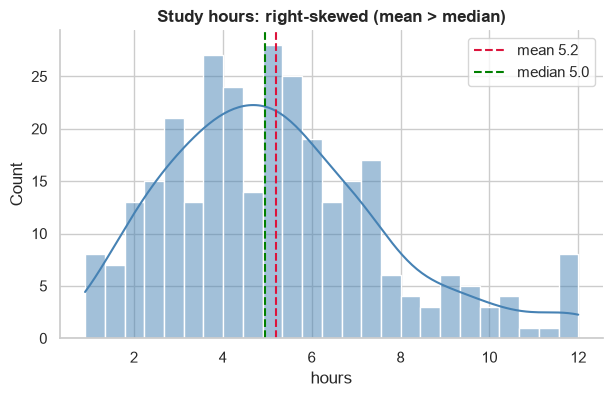

In [16]:
# Seaborn: histogram + smooth curve (KDE). The right tail shows the data is skewed.
sns.histplot(data=students, x="hours", bins=25, kde=True, color="steelblue")
plt.axvline(students["hours"].mean(), color="crimson", linestyle="--", label=f"mean {students['hours'].mean():.1f}")
plt.axvline(students["hours"].median(), color="green", linestyle="--", label=f"median {students['hours'].median():.1f}")
plt.title("Study hours: right-skewed (mean > median)")
plt.legend()
plt.show()

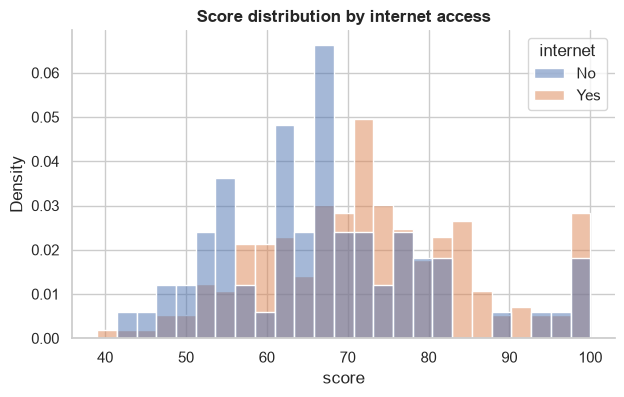

In [17]:
# Compare groups: overlay with hue
sns.histplot(data=students, x="score", hue="internet", bins=25, stat="density", common_norm=False, alpha=0.5)
plt.title("Score distribution by internet access")
plt.show()

## 6.2 Box plot and violin plot

The box shows the **median** (line), the **middle 50%** (box = Q1 to Q3) and **outliers** (dots beyond 1.5 x IQR, chapter 08). A violin adds the shape of the distribution.

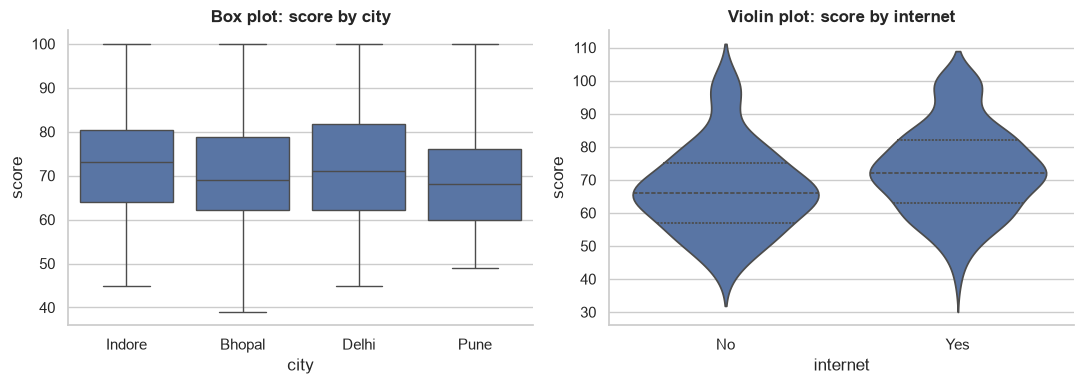

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=students, x="city", y="score", order=["Indore", "Bhopal", "Delhi", "Pune"], ax=axes[0])
axes[0].set_title("Box plot: score by city")

sns.violinplot(data=students, x="internet", y="score", inner="quartile", ax=axes[1])
axes[1].set_title("Violin plot: score by internet")

plt.tight_layout()
plt.show()

## 6.3 Skewed data and the log scale

Money, prices, counts and many "size" variables are **right-skewed**: most values are small, a few are huge. On a normal axis the picture is useless; a **log scale** (or `np.log1p`) reveals the structure.

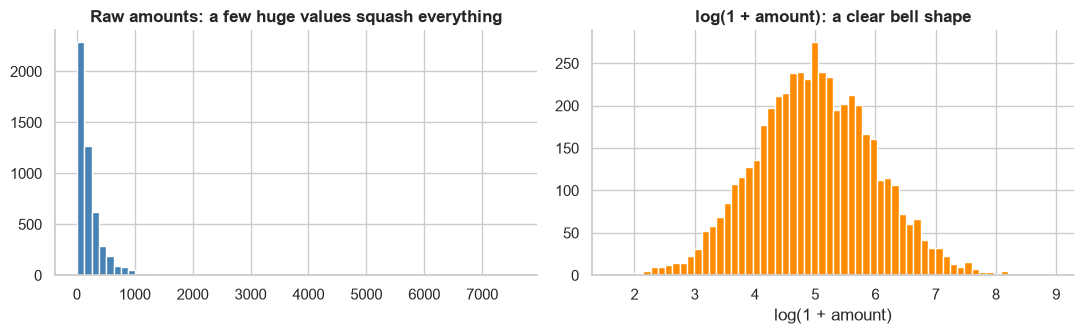

In [19]:
amounts = pd.Series(np.random.default_rng(1).lognormal(5, 1, 5000), name="amount")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(amounts, bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Raw amounts: a few huge values squash everything")

axes[1].hist(np.log1p(amounts), bins=60, color="darkorange", edgecolor="white")
axes[1].set_title("log(1 + amount): a clear bell shape")
axes[1].set_xlabel("log(1 + amount)")

plt.tight_layout()
plt.show()

## 6.4 ECDF: "what fraction is below this value?"

The empirical cumulative distribution has **no bins and no smoothing choices**, and it compares groups cleanly.

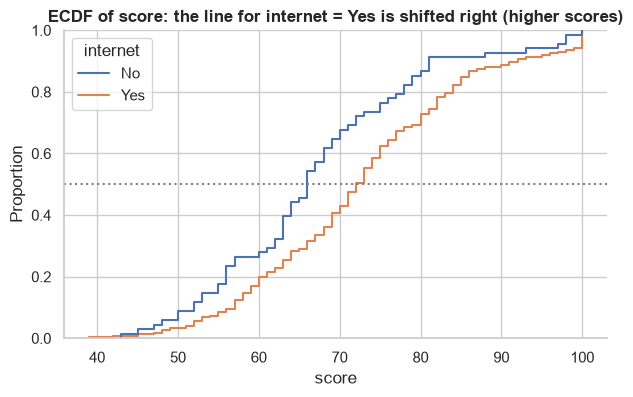

In [20]:
sns.ecdfplot(data=students, x="score", hue="internet")
plt.axhline(0.5, color="gray", linestyle=":")
plt.title("ECDF of score: the line for internet = Yes is shifted right (higher scores)")
plt.show()

---
# 7. Categories

## 7.1 Counts: always sort, use horizontal bars for long labels

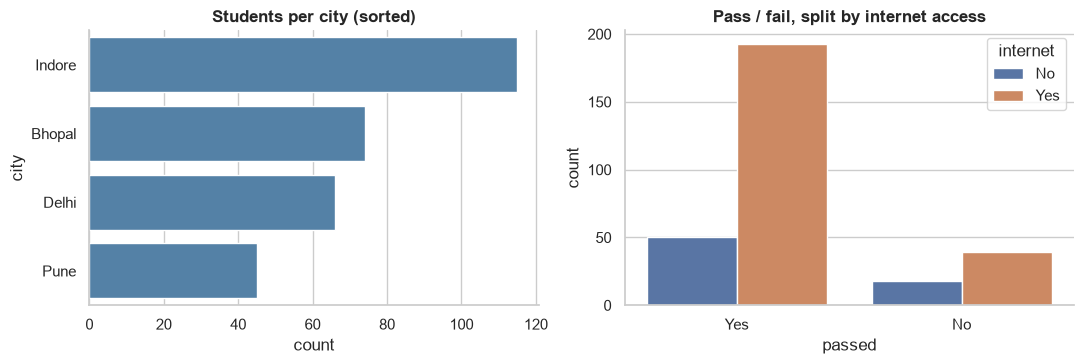

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

order = students["city"].value_counts().index                  # biggest first
sns.countplot(data=students, y="city", order=order, color="steelblue", ax=axes[0])
axes[0].set_title("Students per city (sorted)")

sns.countplot(data=students, x="passed", hue="internet", ax=axes[1])
axes[1].set_title("Pass / fail, split by internet access")

plt.tight_layout()
plt.show()

## 7.2 A number per category: `barplot` shows the **mean with a confidence interval**

The thin line is the uncertainty of the mean (about "where the true average could be"). Overlapping intervals mean the difference may just be noise.

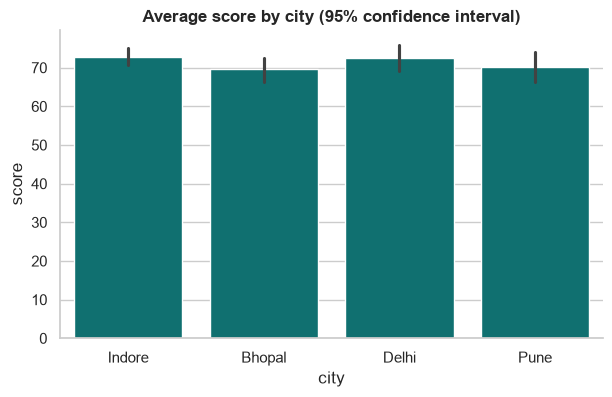

In [22]:
sns.barplot(data=students, x="city", y="score", order=["Indore", "Bhopal", "Delhi", "Pune"], color="teal", errorbar=("ci", 95))
plt.title("Average score by city (95% confidence interval)")
plt.show()

## 7.3 Shares: 100% stacked bars beat pie charts

A pie makes you compare **angles**, which people do badly. Bars compare **lengths**, which people do well.

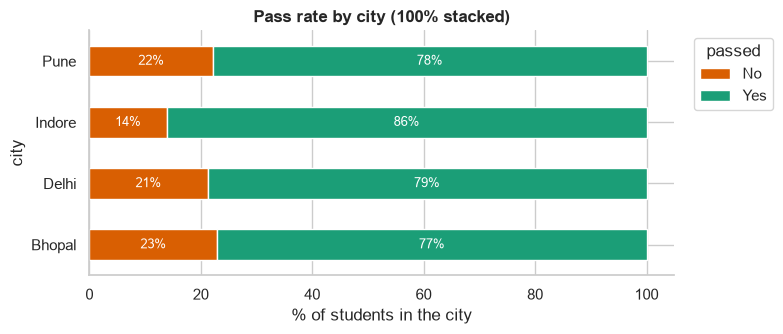

In [23]:
share = pd.crosstab(students["city"], students["passed"], normalize="index") * 100

ax = share.plot.barh(stacked=True, color=["#d95f02", "#1b9e77"], figsize=(8, 3.5))
ax.set_xlabel("% of students in the city")
ax.set_title("Pass rate by city (100% stacked)")
ax.legend(title="passed", bbox_to_anchor=(1.02, 1), loc="upper left")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", label_type="center", color="white", fontsize=9)
plt.tight_layout()
plt.show()

---
# 8. Relationships and correlation

## 8.1 Scatter plots

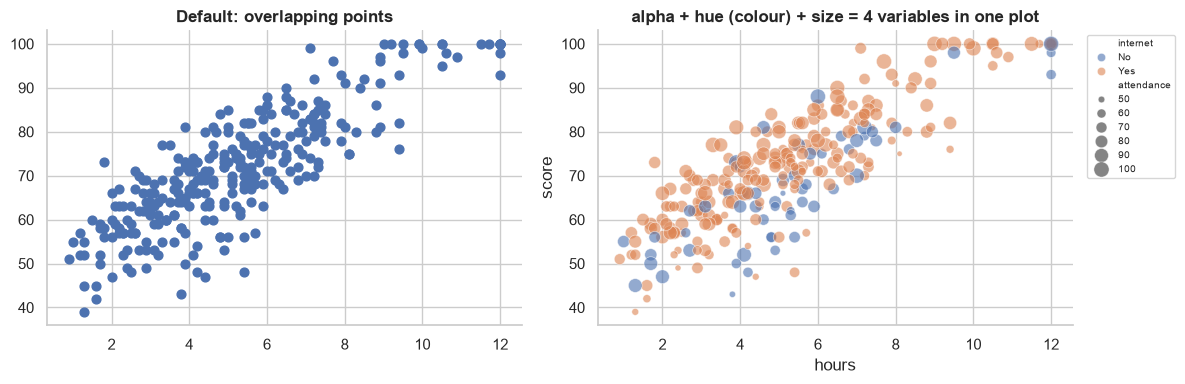

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(students["hours"], students["score"], s=40)                          # points hide each other
axes[0].set_title("Default: overlapping points")

sns.scatterplot(data=students, x="hours", y="score", hue="internet", size="attendance", sizes=(15, 120), alpha=0.6, ax=axes[1])
axes[1].set_title("alpha + hue (colour) + size = 4 variables in one plot")
axes[1].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

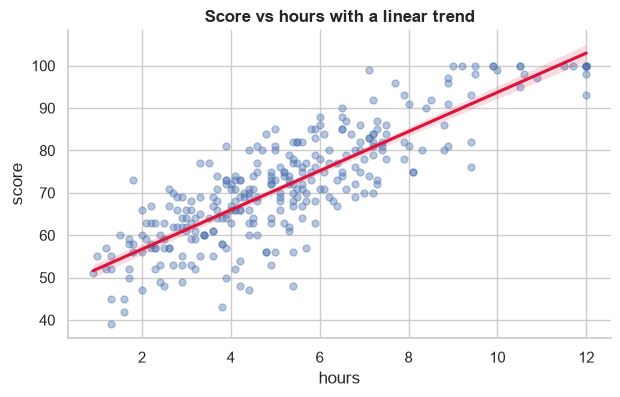

In [25]:
# Add a trend line (and its uncertainty band)
sns.regplot(data=students, x="hours", y="score", scatter_kws={"alpha": 0.4, "s": 25}, line_kws={"color": "crimson"})
plt.title("Score vs hours with a linear trend")
plt.show()

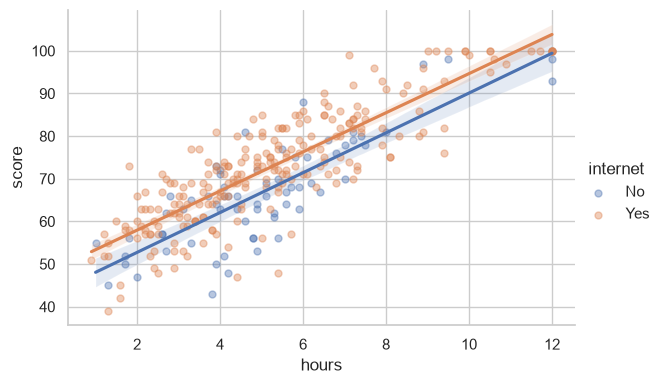

In [26]:
# One trend line per group
sns.lmplot(data=students, x="hours", y="score", hue="internet", height=4, aspect=1.5, scatter_kws={"alpha": 0.4, "s": 25})
plt.show()

## 8.2 Many points: hexbin or 2D density

With 50,000 points a scatter is a solid blob. Counting points per cell shows the density.

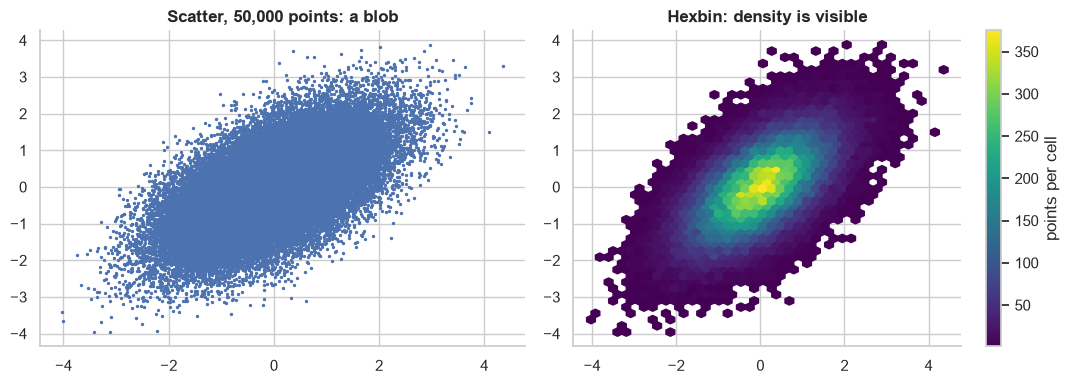

In [27]:
rng2 = np.random.default_rng(5)
x = rng2.normal(0, 1, 50_000)
y = 0.6 * x + rng2.normal(0, 0.8, 50_000)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(x, y, s=2)
axes[0].set_title("Scatter, 50,000 points: a blob")

hb = axes[1].hexbin(x, y, gridsize=40, cmap="viridis", mincnt=1)
fig.colorbar(hb, ax=axes[1], label="points per cell")
axes[1].set_title("Hexbin: density is visible")

plt.tight_layout()
plt.show()

## 8.3 Correlation heatmap

`df.corr()` gives a table of numbers. A heatmap makes it readable. Tips:
- Use a **diverging** colormap centered at **0** (`vmin=-1, vmax=1, center=0`)
- Hide the **upper triangle** (it repeats the lower one)
- Print the numbers (`annot=True`)

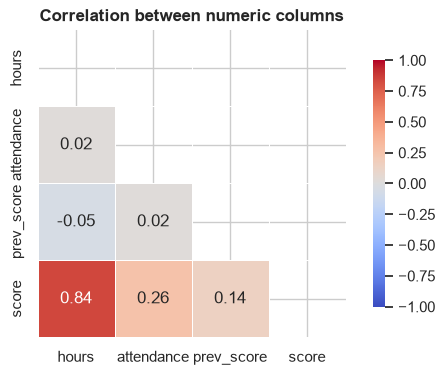

In [28]:
corr = students[["hours", "attendance", "prev_score", "score"]].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))                    # True = hide (upper triangle)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation between numeric columns")
plt.show()

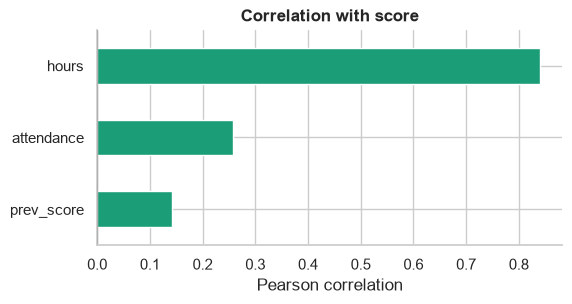

In [29]:
# Correlation of every feature with the TARGET, as a sorted bar chart (a very useful EDA plot)
with_target = students[["hours", "attendance", "prev_score"]].corrwith(students["score"]).sort_values()

with_target.plot.barh(color=["#d95f02" if v < 0 else "#1b9e77" for v in with_target], figsize=(6, 2.8))
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation with score")
plt.xlabel("Pearson correlation")
plt.show()

**Remember:** correlation measures **linear** association only (Anscombe II is a perfect curve with a "good" correlation), it is distorted by outliers (Anscombe III, IV), and it is **not causation**.

## 8.4 Pairplot: all relations at once

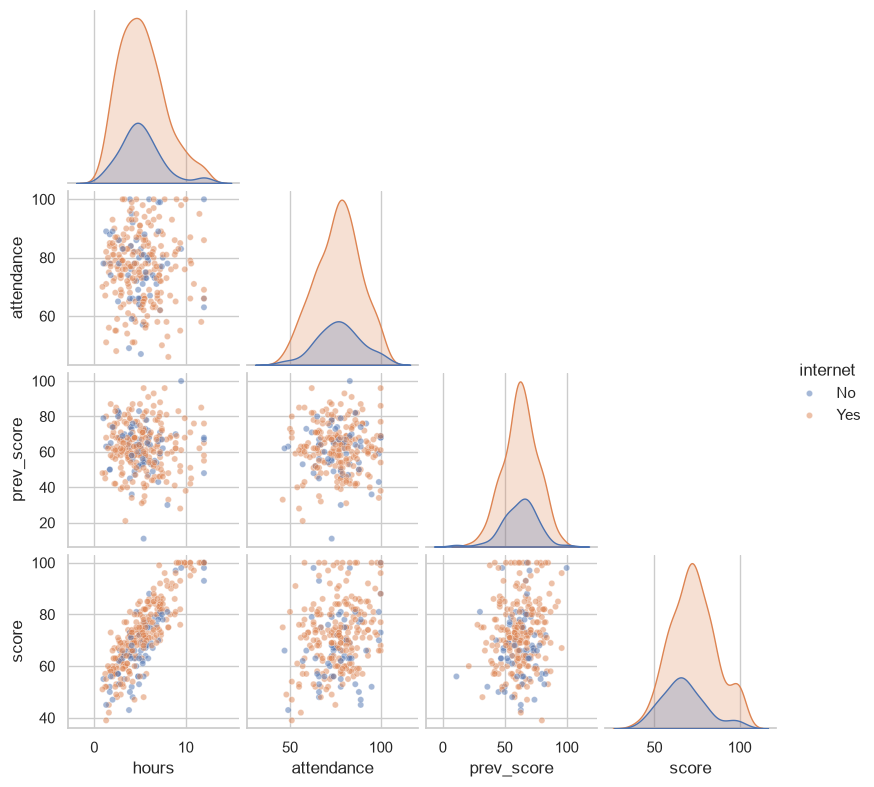

In [30]:
sns.pairplot(students[["hours", "attendance", "prev_score", "score", "internet"]], hue="internet",
             corner=True, height=2, plot_kws={"alpha": 0.5, "s": 20})
plt.show()

The diagonal shows each variable's distribution, the other panels all pairs. With more than about 6-8 columns it becomes unreadable: choose the important ones.

---
# 9. Time series

## 9.1 Line plot + moving averages

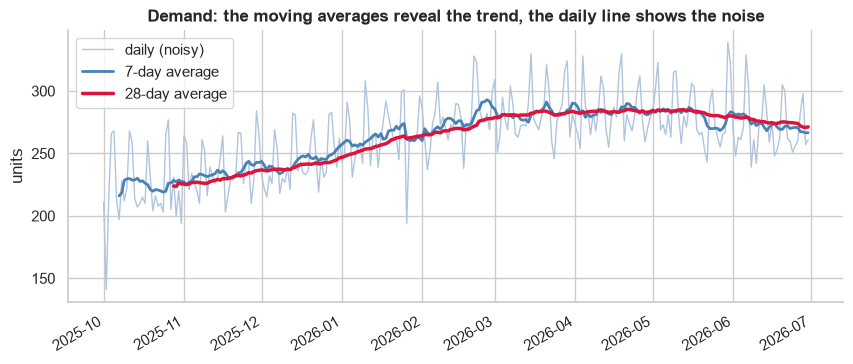

In [31]:
recent = daily["2025-10-01":]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(recent, color="lightsteelblue", linewidth=1, label="daily (noisy)")
ax.plot(recent.rolling(7).mean(), color="steelblue", linewidth=2, label="7-day average")
ax.plot(recent.rolling(28).mean(), color="crimson", linewidth=2.5, label="28-day average")

ax.set_title("Demand: the moving averages reveal the trend, the daily line shows the noise")
ax.set_ylabel("units")
ax.legend(loc="upper left")
fig.autofmt_xdate()
plt.show()

## 9.2 Aggregate with `resample`, then plot

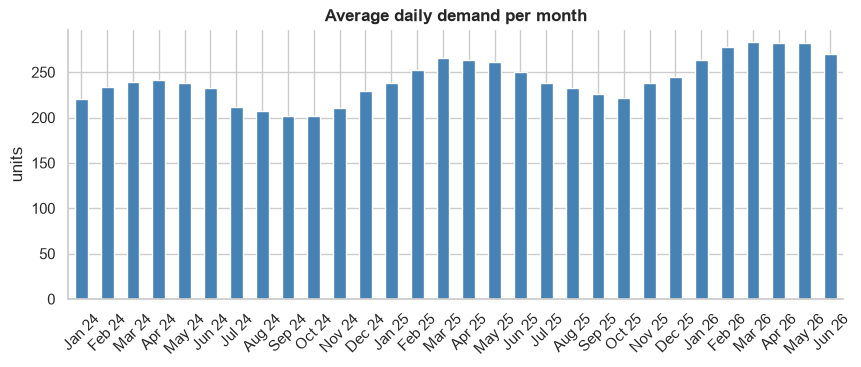

In [32]:
monthly = daily.resample("ME").mean()

fig, ax = plt.subplots(figsize=(10, 3.5))
monthly.plot.bar(ax=ax, color="steelblue")
ax.set_xticklabels([d.strftime("%b %y") for d in monthly.index], rotation=45)
ax.set_title("Average daily demand per month")
ax.set_ylabel("units")
plt.show()

## 9.3 Seasonality: weekday x month heatmap (a pivot, chapter 12)

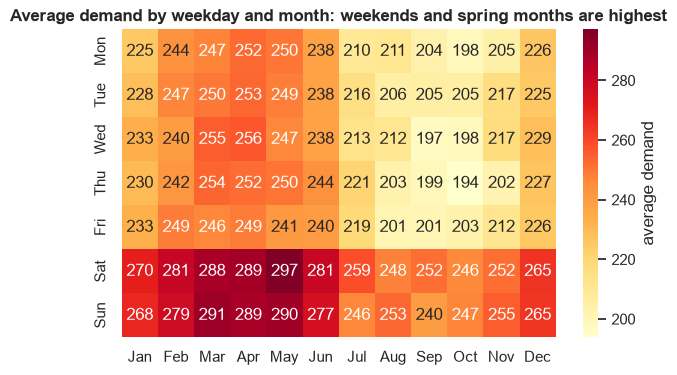

In [33]:
tmp = daily.to_frame()
tmp["month"] = tmp.index.month_name().str[:3]
tmp["weekday"] = tmp.index.day_name().str[:3]

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

grid = tmp.pivot_table(index="weekday", columns="month", values="demand", aggfunc="mean").reindex(index=day_order, columns=month_order)

sns.heatmap(grid, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={"label": "average demand"})
plt.title("Average demand by weekday and month: weekends and spring months are highest")
plt.ylabel("")
plt.xlabel("")
plt.show()

## 9.4 Highlight events and train/test periods

`axvline`, `axvspan` and `scatter` mark important moments on a time axis. This kind of plot is great for showing a **time-based train/test split** (chapter 13).

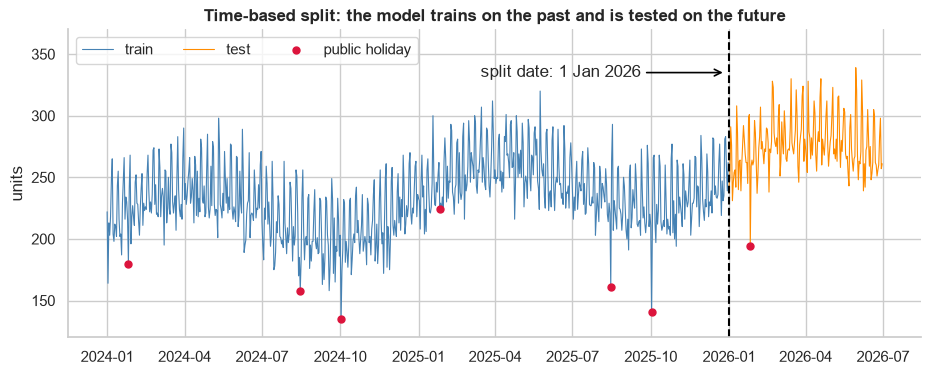

In [34]:
fig, ax = plt.subplots(figsize=(11, 4))

train = daily[:"2025-12-31"]
test = daily["2026-01-01":]

ax.plot(train, color="steelblue", linewidth=0.8, label="train")
ax.plot(test, color="darkorange", linewidth=0.8, label="test")
ax.axvline(pd.Timestamp("2026-01-01"), color="black", linestyle="--")
ax.set_ylim(120, 370)
ax.annotate("split date: 1 Jan 2026", xy=(pd.Timestamp("2025-12-28"), 335), xytext=(pd.Timestamp("2025-03-15"), 335),
            va="center", arrowprops=dict(arrowstyle="->", color="black", lw=1.2))

holiday_values = daily.reindex(HOLIDAYS)
ax.scatter(holiday_values.index, holiday_values.values, color="crimson", s=25, zorder=3, label="public holiday")

ax.set_title("Time-based split: the model trains on the past and is tested on the future")
ax.set_ylabel("units")
ax.legend(loc="upper left", ncol=3)
plt.show()

---
# 10. Missing values

A picture of **where** data is missing shows patterns that counts hide (chapter 07: is it random, or does it depend on another column?).

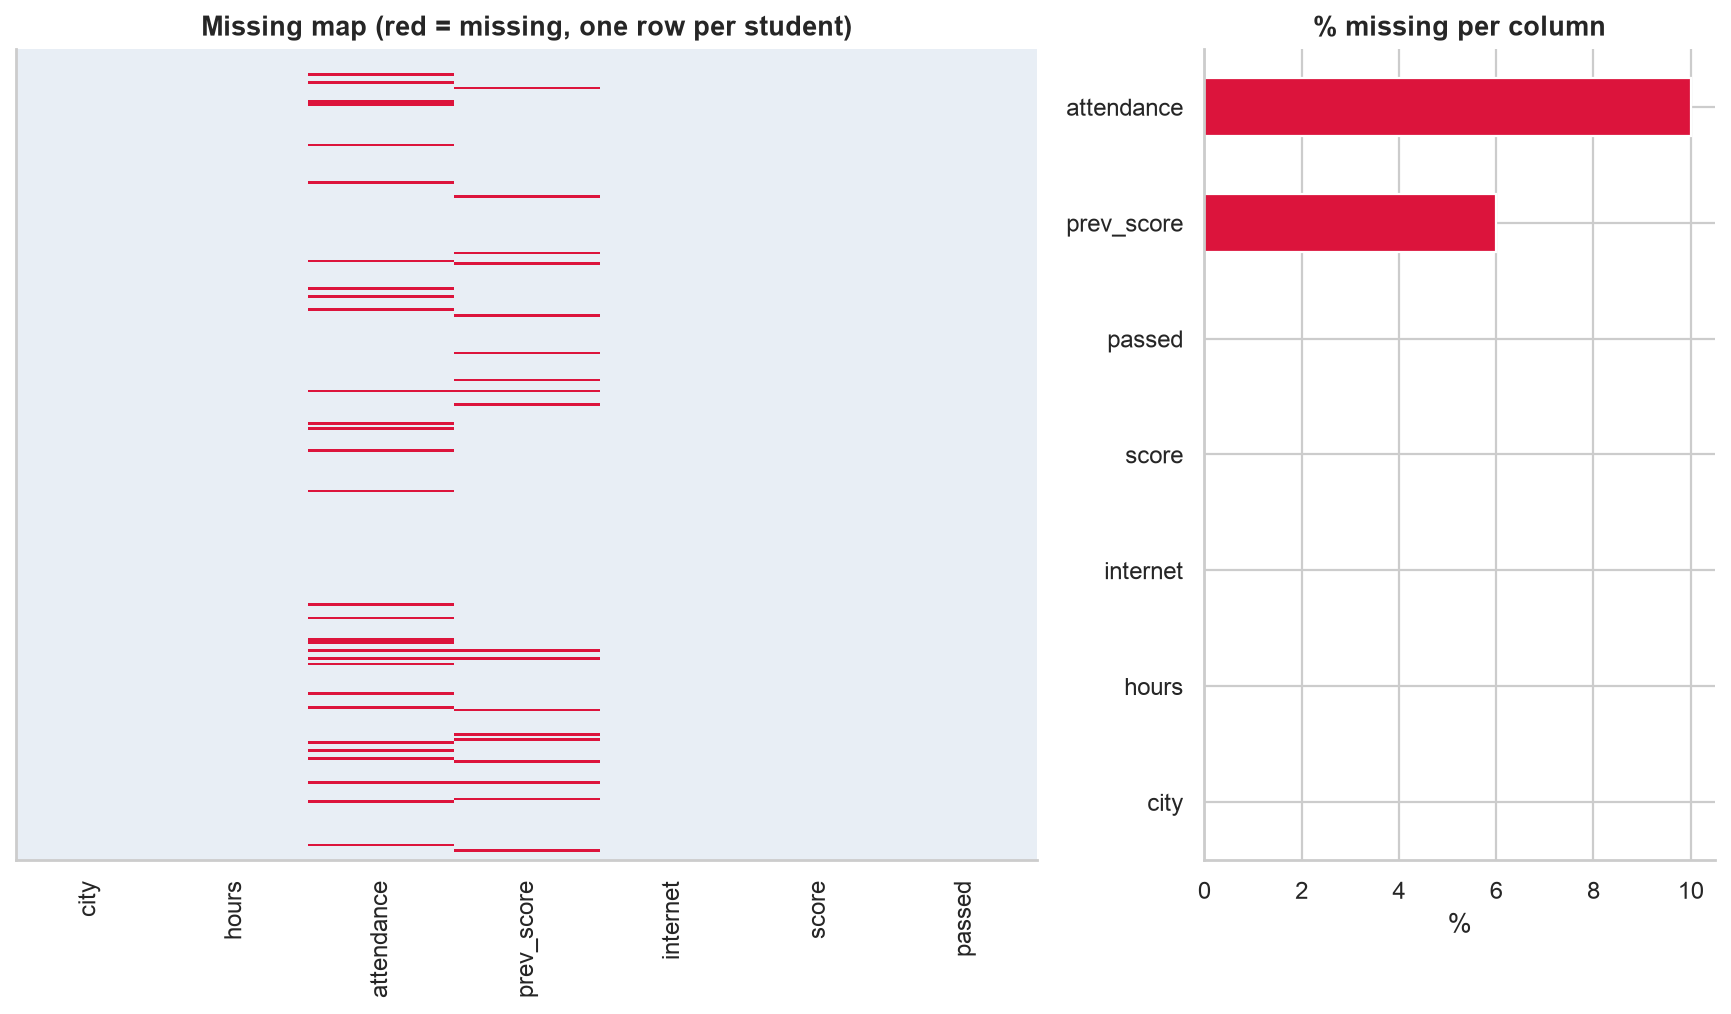

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(11, 6.5), dpi=160, gridspec_kw={"width_ratios": [2, 1]})   # tall + sharp: every row gets several pixels

# imshow draws every cell as pixels (no cell borders), which is cleaner than a heatmap for 300+ thin rows
axes[0].imshow(students.isna().to_numpy(), aspect="auto", interpolation="nearest", cmap=ListedColormap(["#e8eef5", "crimson"]))
axes[0].set_xticks(range(students.shape[1]))
axes[0].set_xticklabels(students.columns, rotation=90)
axes[0].set_yticks([])
axes[0].grid(False)
axes[0].set_title("Missing map (red = missing, one row per student)")

missing_pct = (students.isna().mean() * 100).sort_values()
missing_pct.plot.barh(ax=axes[1], color="crimson")
axes[1].set_title("% missing per column")
axes[1].set_xlabel("%")

plt.tight_layout()
plt.show()

In [36]:
# Is missingness related to another column? (a check for MAR)
students.assign(attendance_missing=students["attendance"].isna()).groupby("internet")["attendance_missing"].mean().mul(100).round(1)

internet
No     16.2
Yes     8.2
Name: attendance_missing, dtype: float64

---
# 11. ML plots: target, features, model results

## 11.1 The target: class balance and distribution

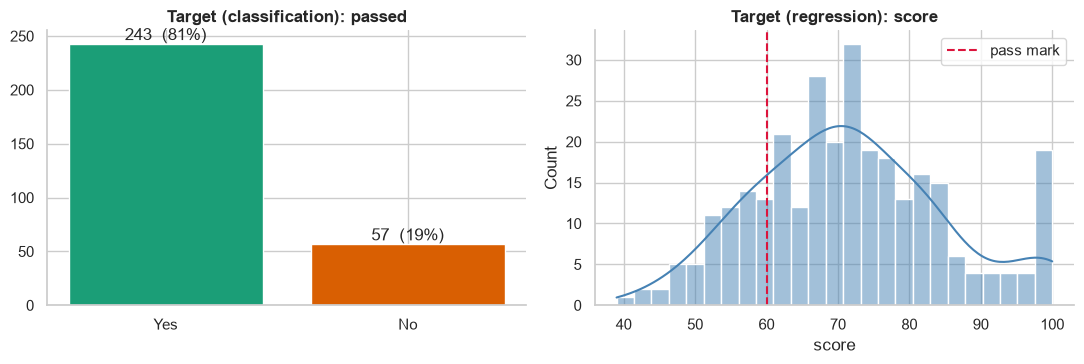

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

counts = students["passed"].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=["#1b9e77", "#d95f02"])
axes[0].bar_label(bars, labels=[f"{v}  ({v / len(students):.0%})" for v in counts.values])
axes[0].set_title("Target (classification): passed")

sns.histplot(students["score"], bins=25, kde=True, ax=axes[1], color="steelblue")
axes[1].axvline(60, color="crimson", linestyle="--", label="pass mark")
axes[1].legend()
axes[1].set_title("Target (regression): score")

plt.tight_layout()
plt.show()

If one class is much rarer, accuracy becomes misleading (a model that always says "pass" would be right most of the time). Look at class balance **before** choosing metrics.

## 11.2 Features vs target

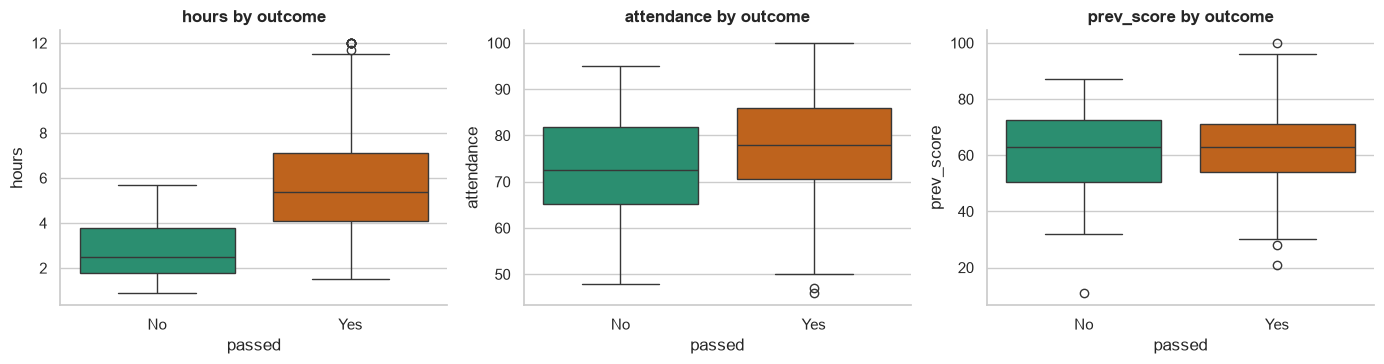

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

for ax, col in zip(axes, ["hours", "attendance", "prev_score"]):
    sns.boxplot(data=students, x="passed", y=col, order=["No", "Yes"], palette=["#d95f02", "#1b9e77"], hue="passed", legend=False, ax=ax)
    ax.set_title(f"{col} by outcome")

plt.tight_layout()
plt.show()

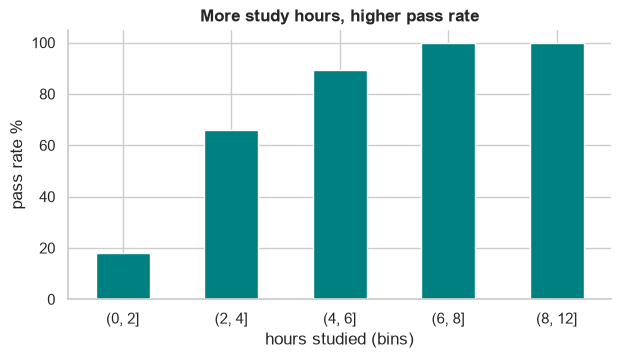

In [39]:
# Pass rate for bins of a feature: an intuitive way to see a feature's signal (and a good encoding idea)
bins = pd.cut(students["hours"], bins=[0, 2, 4, 6, 8, 12])
rate = students.groupby(bins, observed=True)["passed"].apply(lambda s: (s == "Yes").mean() * 100)

rate.plot.bar(color="teal", figsize=(7, 3.5))
plt.ylabel("pass rate %")
plt.xlabel("hours studied (bins)")
plt.title("More study hours, higher pass rate")
plt.xticks(rotation=0)
plt.show()

## 11.3 Model results: regression

We fit a simple linear regression with NumPy (as in chapter 13) and plot what every regression report needs:

1. **Predicted vs actual** (points close to the diagonal = good)
2. **Residuals vs predicted** (random scatter around 0 = good, a pattern = the model misses something)
3. **Residual histogram** (roughly centred at 0)
4. **Coefficients** (which features matter)

In [40]:
data = students.dropna(subset=["attendance", "prev_score"]).reset_index(drop=True)
features = ["hours", "attendance", "prev_score", "internet_yes"]
data["internet_yes"] = (data["internet"] == "Yes").astype(float)

X = np.column_stack([np.ones(len(data)), data[features].to_numpy(float)])
y = data["score"].to_numpy(float)

order = np.random.default_rng(1).permutation(len(data))
cut = int(0.8 * len(data))
train_idx, test_idx = order[:cut], order[cut:]

coef, *_ = np.linalg.lstsq(X[train_idx], y[train_idx], rcond=None)
pred = X[test_idx] @ coef
actual = y[test_idx]
resid = actual - pred

print(f"test MAE: {np.abs(resid).mean():.2f} | R2: {1 - (resid ** 2).sum() / ((actual - actual.mean()) ** 2).sum():.3f}")

test MAE: 4.02 | R2: 0.875


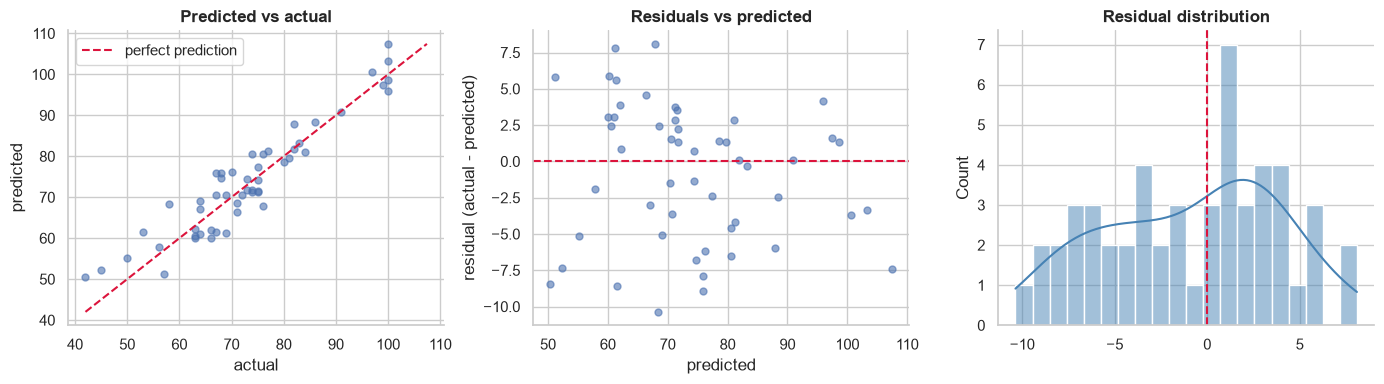

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(actual, pred, alpha=0.6, s=25)
lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
axes[0].plot(lims, lims, color="crimson", linestyle="--", label="perfect prediction")
axes[0].set_xlabel("actual"); axes[0].set_ylabel("predicted"); axes[0].legend()
axes[0].set_title("Predicted vs actual")

axes[1].scatter(pred, resid, alpha=0.6, s=25)
axes[1].axhline(0, color="crimson", linestyle="--")
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("residual (actual - predicted)")
axes[1].set_title("Residuals vs predicted")

sns.histplot(resid, bins=20, kde=True, ax=axes[2], color="steelblue")
axes[2].axvline(0, color="crimson", linestyle="--")
axes[2].set_title("Residual distribution")

plt.tight_layout()
plt.show()

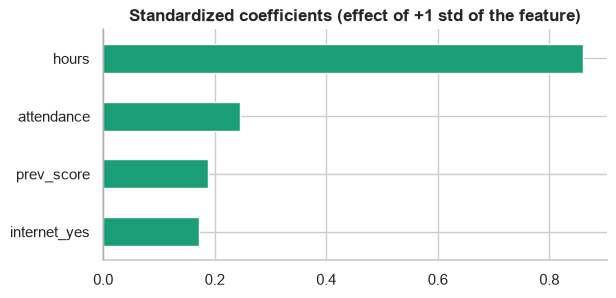

In [42]:
# Feature importance for a linear model: standardized coefficients (comparable across features)
std_coef = pd.Series(coef[1:] * data[features].std().to_numpy() / y.std(), index=features).sort_values()

std_coef.plot.barh(color=["#d95f02" if v < 0 else "#1b9e77" for v in std_coef], figsize=(6.5, 3))
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Standardized coefficients (effect of +1 std of the feature)")
plt.show()

## 11.4 Model results: classification (confusion matrix)

Turn the same regression into a pass/fail classifier (`prediction >= 60`) and plot the **confusion matrix**.

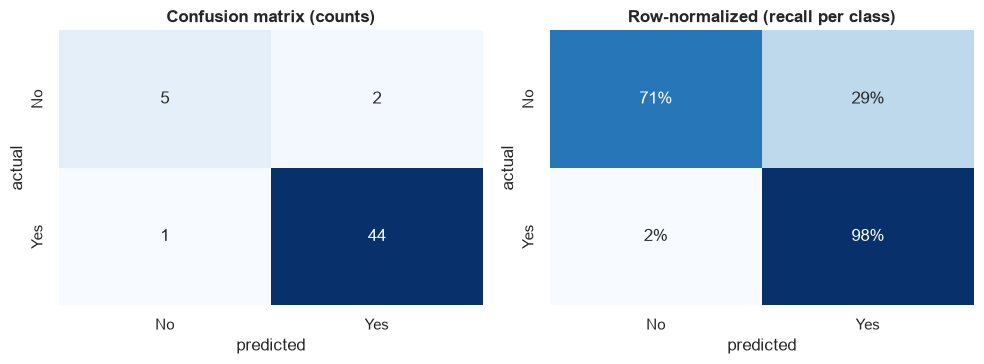

accuracy 0.94 | precision 0.96 | recall 0.98


In [43]:
actual_pass = np.where(actual >= 60, "Yes", "No")
pred_pass = np.where(pred >= 60, "Yes", "No")

cm = pd.crosstab(pd.Series(actual_pass, name="actual"), pd.Series(pred_pass, name="predicted")).reindex(index=["No", "Yes"], columns=["No", "Yes"], fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Confusion matrix (counts)")

sns.heatmap(cm.div(cm.sum(axis=1), axis=0), annot=True, fmt=".0%", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("Row-normalized (recall per class)")

plt.tight_layout()
plt.show()

tp, fn, fp = cm.loc["Yes", "Yes"], cm.loc["Yes", "No"], cm.loc["No", "Yes"]
print(f"accuracy {(cm.values.diagonal().sum() / cm.values.sum()):.2f} | precision {tp / (tp + fp):.2f} | recall {tp / (tp + fn):.2f}")

**Careful with small numbers:** the test set has only about 50 students, so one student moves a percentage a lot (in the "No" row, one student is about 14%). Never read much into a confusion matrix built on so few rows.

Each cell answers a question: top-left = correctly predicted **fail**, bottom-right = correctly predicted **pass**, the off-diagonal cells are the **mistakes**. Normalizing by row shows how well each real class is found (recall).

**ML plot checklist:**
- Before modelling: target balance, feature distributions, missing map, correlation with target
- After modelling: predicted vs actual, residuals, confusion matrix, feature importance, results per group (is the model worse for one city?)
- Time series: train/test timeline, forecast vs actual with the baseline

---
# 12. Making charts honest and readable

## 12.1 The truncated axis lie

A bar chart's **bars must start at zero**, because the **length** is the data. Cutting the axis exaggerates tiny differences.

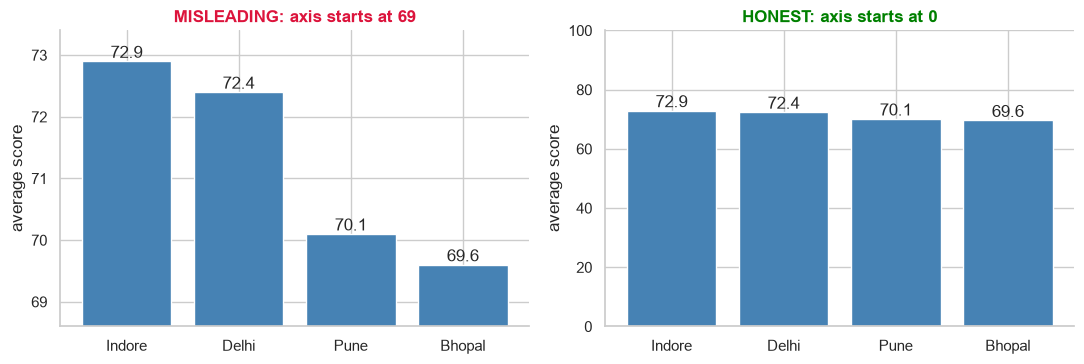

In [44]:
city_avg = students.groupby("city")["score"].mean().round(1).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].bar(city_avg.index, city_avg.values, color="steelblue")
axes[0].set_ylim(city_avg.min() - 1, city_avg.max() + 0.5)
axes[0].set_title("MISLEADING: axis starts at %.0f" % (city_avg.min() - 1), color="crimson")

axes[1].bar(city_avg.index, city_avg.values, color="steelblue")
axes[1].set_ylim(0, 100)
axes[1].set_title("HONEST: axis starts at 0", color="green")

for ax in axes:
    ax.bar_label(ax.containers[0], fmt="%.1f")
    ax.set_ylabel("average score")

plt.tight_layout()
plt.show()

(Line charts and scatter plots do **not** need a zero baseline: there the **position and slope** matter, not the length.)

## 12.2 Default vs designed

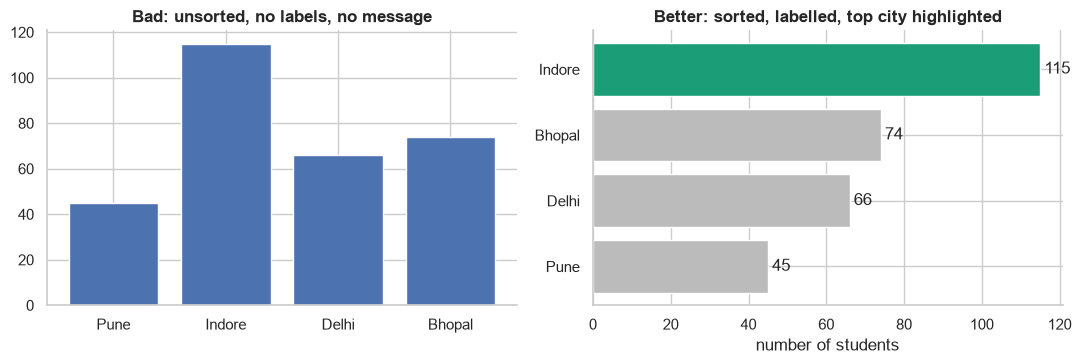

In [45]:
raw_counts = students["city"].value_counts()
unsorted = raw_counts.reindex(["Pune", "Indore", "Delhi", "Bhopal"])        # arbitrary order, like data often arrives

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].bar(unsorted.index, unsorted.values)
axes[0].set_title("Bad: unsorted, no labels, no message")

best = raw_counts.sort_values()
bars = axes[1].barh(best.index, best.values, color=["#bbbbbb"] * (len(best) - 1) + ["#1b9e77"])
axes[1].bar_label(bars, padding=3)
axes[1].set_title("Better: sorted, labelled, top city highlighted")
axes[1].set_xlabel("number of students")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 12.3 Rules that make charts good

1. **Title says the insight**, not just the variables ("Weekend demand is 20% higher", not "Demand by day").
2. **Label axes with units.** Add a legend only when needed.
3. **Sort** categories by value (unless they have a natural order like months).
4. **Bars start at zero.** No 3D effects, no decoration.
5. **One message per chart.** Many series or colours: split into small multiples (`col=`, `subplots`).
6. **Direct labels** (`bar_label`, `annotate`) beat legends and gridlines.
7. **Highlight** what matters with colour, make the rest gray.
8. **Right chart type** for the question (section 5).
9. **Consistency:** same colours for the same meaning across all charts of a report.
10. **Test it:** can someone understand it in 5 seconds?

## 12.4 Colour

| Data type | Palette | Examples |
|---|---|---|
| **Sequential** (low to high) | one hue, light to dark | `viridis`, `Blues`, `YlOrRd` |
| **Diverging** (negative / zero / positive) | two hues meeting at a neutral centre | `coolwarm`, `RdBu` (use `center=0`) |
| **Categorical** (unordered groups) | distinct hues, max about 6-8 | `colorblind`, `Set2` |

About 8% of men have some colour-vision deficiency: prefer the **`colorblind`** palette (`sns.set_palette("colorblind")`) and do not rely on red vs green alone.

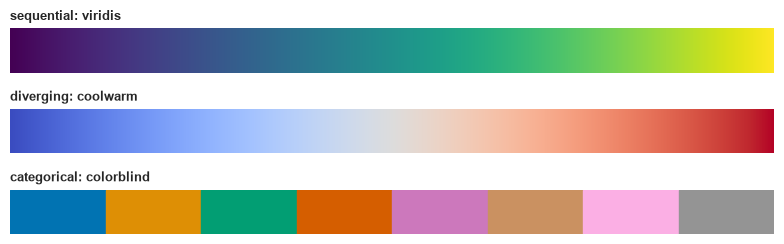

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(8, 2.6))
gradient = np.linspace(0, 1, 256).reshape(1, -1)

for ax, (name, cmap) in zip(axes, [("sequential: viridis", "viridis"), ("diverging: coolwarm", "coolwarm")]):
    ax.imshow(gradient, aspect="auto", cmap=cmap)
    ax.set_title(name, fontsize=9, loc="left")
    ax.axis("off")

for i, c in enumerate(sns.color_palette("colorblind", 8)):
    axes[2].add_patch(plt.Rectangle((i, 0), 1, 1, color=c))
axes[2].set_xlim(0, 8); axes[2].set_ylim(0, 1)
axes[2].set_title("categorical: colorblind", fontsize=9, loc="left")
axes[2].axis("off")

plt.tight_layout()
plt.show()

---
# 13. Saving figures and a reusable `quick_eda()`

## 13.1 Saving

In [47]:
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 3.5))
students.groupby("city")["score"].mean().sort_values().plot.barh(ax=ax, color="teal")
ax.set_title("Average score by city")
ax.set_xlabel("average score")

fig.savefig(FIG / "avg_score_by_city.png", dpi=200, bbox_inches="tight")      # PNG for slides and reports
fig.savefig(FIG / "avg_score_by_city.svg", bbox_inches="tight")               # SVG: sharp at any size
plt.close(fig)

print(sorted(p.name for p in FIG.iterdir()))

['avg_score_by_city.png', 'avg_score_by_city.svg']


- **PNG** with `dpi=200` for documents and slides, **SVG/PDF** for print and sharp scaling.
- `bbox_inches="tight"` stops labels from being cut off.
- Call `fig.savefig(...)` **before** `plt.show()` in a script (show can clear the figure).

## 13.2 A reusable EDA dashboard

One function that gives a first visual overview of **any** DataFrame. Copy it into your project.

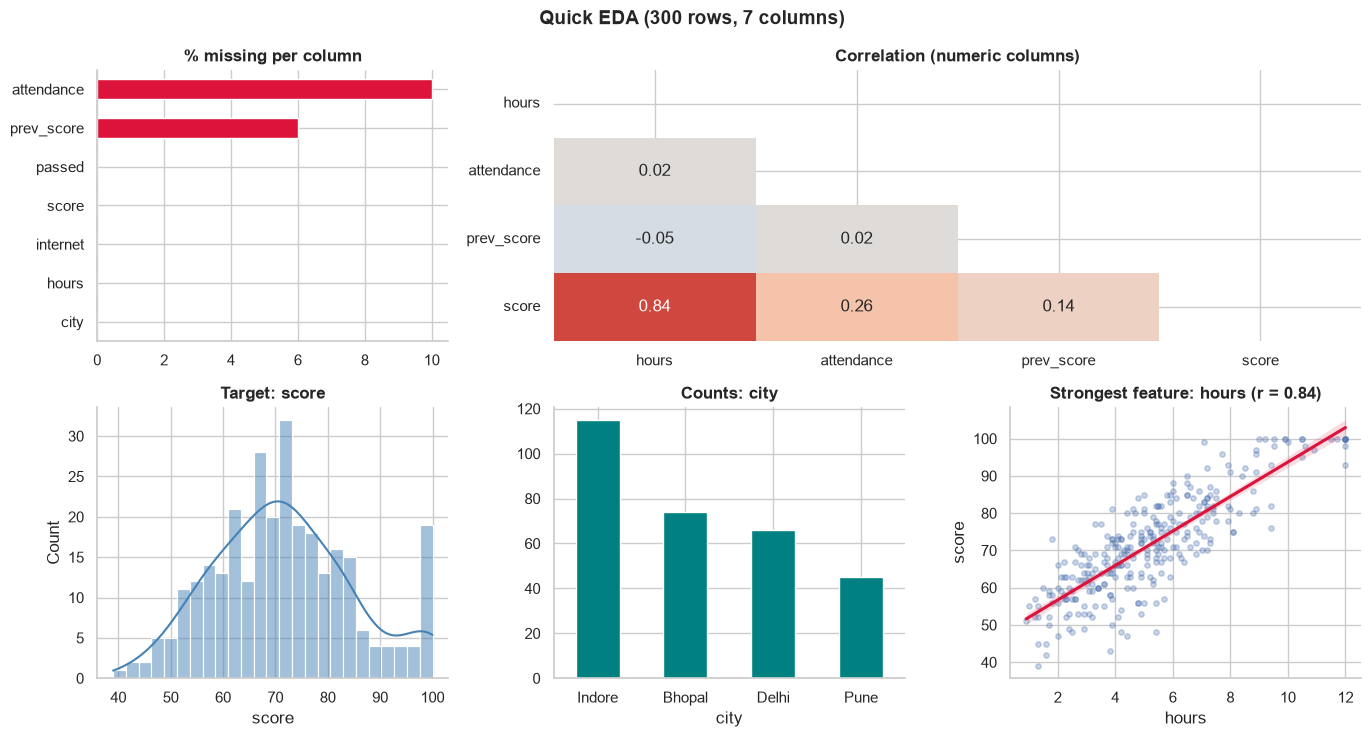

In [48]:
def quick_eda(df, target):
    """One-page visual overview: missing %, correlations, target distribution, a category count, best feature vs target."""
    num_cols = df.select_dtypes("number").columns.tolist()
    cat_cols = [c for c in df.select_dtypes(exclude="number").columns if c != target]

    fig = plt.figure(figsize=(14, 7.5))
    gs = fig.add_gridspec(2, 3)

    # 1. missing values
    ax = fig.add_subplot(gs[0, 0])
    miss = (df.isna().mean() * 100).sort_values()
    miss.plot.barh(ax=ax, color="crimson")
    ax.set_title("% missing per column")

    # 2. correlation heatmap (numeric columns)
    ax = fig.add_subplot(gs[0, 1:])
    corr = df[num_cols].corr()
    sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, center=0, cbar=False, ax=ax)
    ax.set_title("Correlation (numeric columns)")

    # 3. target distribution
    ax = fig.add_subplot(gs[1, 0])
    if target in num_cols:
        sns.histplot(df[target], bins=25, kde=True, ax=ax, color="steelblue")
    else:
        df[target].value_counts().plot.bar(ax=ax, color="steelblue", rot=0)
    ax.set_title(f"Target: {target}")

    # 4. first categorical column
    ax = fig.add_subplot(gs[1, 1])
    if cat_cols:
        df[cat_cols[0]].value_counts().plot.bar(ax=ax, color="teal", rot=0)
        ax.set_title(f"Counts: {cat_cols[0]}")
    else:
        ax.axis("off")

    # 5. numeric feature most correlated with the target (only if the target is numeric)
    ax = fig.add_subplot(gs[1, 2])
    if target in num_cols:
        best = corr[target].drop(target).abs().idxmax()
        sns.regplot(data=df, x=best, y=target, ax=ax, scatter_kws={"alpha": 0.3, "s": 15}, line_kws={"color": "crimson"})
        ax.set_title(f"Strongest feature: {best} (r = {corr.loc[best, target]:.2f})")
    else:
        ax.axis("off")

    fig.suptitle(f"Quick EDA ({df.shape[0]} rows, {df.shape[1]} columns)", fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()


quick_eda(students, target="score")

---
# 14. Pandas 3.x notes

- `df.plot` needs **Matplotlib** installed (`pip install matplotlib`). Seaborn is optional.
- Text columns use the `str` dtype. They plot as categories without problems. For a **custom order** use `order=[...]` in Seaborn, or an ordered `Categorical` (chapter 09).
- Datetime columns are `datetime64[us]`: plotting against dates works as before. Use `fig.autofmt_xdate()` for readable tick labels.
- Resample aliases are `"ME"`, `"QE"`, `"YE"`, `"h"` (chapter 13): `daily.resample("ME").mean().plot()`.
- `groupby` uses `observed=True` by default, so empty categories do not show as empty bars. Use `observed=False` if you want them.
- Seaborn expects **long** data for `hue` / `col`. Wide tables: `df.melt(...)` first (chapter 12).
- Notebook plots show automatically (inline backend). In **scripts** call `plt.show()` or `fig.savefig(...)`.

---
# 15. Common mistakes

| Mistake | Fix |
|---|---|
| Trusting `describe()`/`corr()` without a plot | Plot first (Anscombe) |
| Using `plt.plot` for several figures and mixing them up | Object-oriented API: `fig, ax = plt.subplots()` |
| Overlapping labels | `fig.tight_layout()`, `rotation=45`, `fig.autofmt_xdate()`, horizontal bars |
| Unsorted bars | `.sort_values()` before plotting |
| Truncated axis on bar charts | Bars start at 0 |
| Pie charts with many slices | Sorted bars or 100% stacked bars |
| Too few or too many histogram bins | Try several (`bins=` 10, 30, 60) or use `kde`/`ecdf` |
| Skewed money data on a linear axis | Log scale or `np.log1p` |
| Scatter of thousands of points is a blob | `alpha`, `hexbin`, density plots |
| Correlation heatmap with full square and default colours | Mask the upper triangle, diverging colormap, `center=0` |
| Dual y-axes comparing unrelated scales | Two separate plots (`sharex=True`) |
| Rainbow colormaps for ordered data | Sequential (`viridis`) or diverging (`coolwarm`) |
| Red/green only for good/bad | Colorblind-safe palette plus labels |
| Seaborn with wide data and `hue` | `melt` to long format |
| Titles like "Plot 1" | A title that states the insight |
| Evaluating classifiers only by accuracy | Confusion matrix, class balance |
| Forgetting `plt.show()`/`savefig` in scripts | Add it, and `plt.close(fig)` in loops (memory) |
| Plot looks different from what you want, no idea why | Check `df.dtypes`, `df.index`, and sort order first |

---
# 16. Interview questions

**Q1. Why visualize data before modelling?**
Statistics can hide structure (Anscombe's quartet): outliers, curves, clusters, wrong data. Plots reveal distributions, skew, missing patterns, relationships and data errors that change the modelling choices.

**Q2. Matplotlib vs Seaborn vs pandas `.plot`?**
Matplotlib is the low-level base with full control. pandas `.plot` is a quick wrapper for Series/DataFrames. Seaborn adds statistical plots and works well with long-format DataFrames and grouping (`hue`). They all draw on Matplotlib axes, so they can be combined.

**Q3. What is the difference between `Figure` and `Axes`?**
The Figure is the whole canvas, an Axes is one plot inside it (with its own axes, title, labels). `fig, ax = plt.subplots()` creates both.

**Q4. How do you check the distribution of a numeric feature?**
Histogram + KDE, box/violin plot, ECDF, plus `skew()`/`describe()`. Look for skew, outliers and multiple peaks, and decide on log transforms or outlier handling.

**Q5. How do you read a box plot?**
Line = median, box = Q1 to Q3 (middle 50%), whiskers = about 1.5 x IQR, dots = outliers. Boxes of different groups show differences in centre and spread.

**Q6. How do you plot the relationship between two numeric variables, and what if there are 1 million points?**
Scatter with a trend line. For huge data use alpha, hexbin or 2D density plots, or a random sample.

**Q7. What should a correlation heatmap include?**
A diverging colormap centred at 0 (`vmin=-1, vmax=1`), the upper triangle masked, annotations, and the awareness that correlation is linear and not causation.

**Q8. Which plots do you use to evaluate a regression model?**
Predicted vs actual (with the diagonal), residuals vs predicted (should look random around 0), the residual histogram, and coefficient/feature importance charts.

**Q9. How do you evaluate a classifier visually?**
Confusion matrix (counts and normalized), ROC and precision-recall curves, class balance of the target, and results per subgroup.

**Q10. Why must bar charts start at zero?**
The length of a bar encodes the value. A truncated axis exaggerates small differences and misleads. Line charts and scatter plots do not have this requirement.

**Q11. How do you show a time-based train/test split?**
Plot the whole series with train and test in different colours and a vertical line at the split date. It makes it obvious that the model only sees the past.

**Q12. How do you handle highly skewed data in a plot?**
Use a log scale on the axis or `np.log1p` the values, so structure in the small values becomes visible.

---
# 17. Practice questions

Run this cell first to get the practice data.

In [49]:
rng = np.random.default_rng(3)
m = 240

retail = pd.DataFrame({
    "date":     pd.date_range("2025-01-01", periods=m, freq="D"),
    "region":   rng.choice(["North", "South", "East", "West"], m),
    "category": rng.choice(["Electronics", "Grocery", "Fashion", "Home", "Toys"], m, p=[0.2, 0.35, 0.2, 0.15, 0.1]),
    "price":    rng.lognormal(4, 0.7, m).round(2),
    "units":    rng.integers(1, 20, m).astype(float),
})
retail["sales"] = (retail["price"] * retail["units"]).round(0)
retail.loc[rng.choice(m, 25, replace=False), "units"] = np.nan          # some missing values

y_true = rng.normal(100, 20, 80)
y_pred = y_true * 0.9 + 12 + rng.normal(0, 6, 80)

retail.head()

,date,region,category,price,units,sales
0,2025-01-01,West,Toys,31.04,NaN,248.0
1,2025-01-02,North,Home,83.72,12.0,1005.0
2,2025-01-03,North,Fashion,81.77,14.0,1145.0
3,2025-01-04,North,Home,279.47,1.0,279.0
4,2025-01-05,North,Home,43.14,6.0,259.0


**Q1.** Plot the daily `sales` total as a line chart with a title and axis labels (group by `date` first).
**Q2.** Horizontal bar chart of the average `sales` per `category`, sorted, with the values written on the bars.
**Q3.** Histogram of `price` with vertical lines for the mean and the median and a legend. Why are they different?
**Q4.** Box plot of `price` per `category` (Seaborn). Which category has the widest spread?
**Q5.** Scatter plot of `price` vs `sales` coloured by `region`, with a trend line per region (`lmplot`).
**Q6.** Correlation heatmap of the numeric columns (lower triangle only, annotated, centered at 0).
**Q7.** 100% stacked horizontal bar: the share of each `category` inside each `region`.
**Q8.** Monthly total `sales` as bars, with a 3-month rolling average line on the same axes.
**Q9.** A 2x2 figure with four different charts of your choice, with one overall title and no overlapping labels.
**Q10.** The chart below is misleading. Draw the honest version next to it:
`values = pd.Series({"A": 98.2, "B": 99.1, "C": 99.5})` plotted as bars with the y-axis limited to (98, 100).
**Q11.** Missing map (heatmap of `isna()`) and a bar of missing percentages for `retail`.
**Q12.** Using `y_true` and `y_pred`: predicted vs actual with a diagonal, and a residual plot side by side.

### Solutions

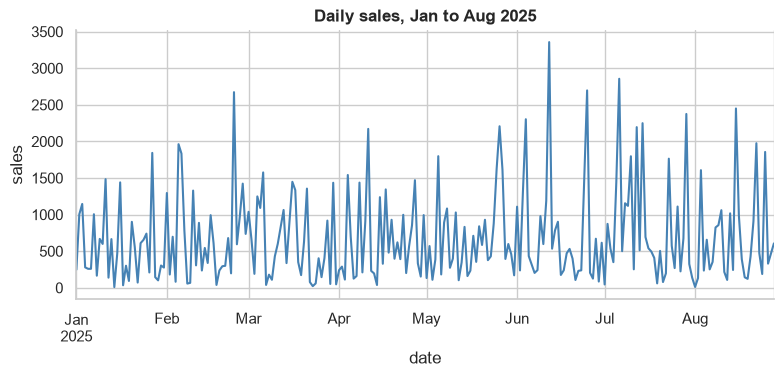

In [50]:
# Q1
daily_sales = retail.groupby("date")["sales"].sum()
ax = daily_sales.plot(figsize=(9, 3.5), color="steelblue", title="Daily sales, Jan to Aug 2025")
ax.set_xlabel("date"); ax.set_ylabel("sales")
plt.show()

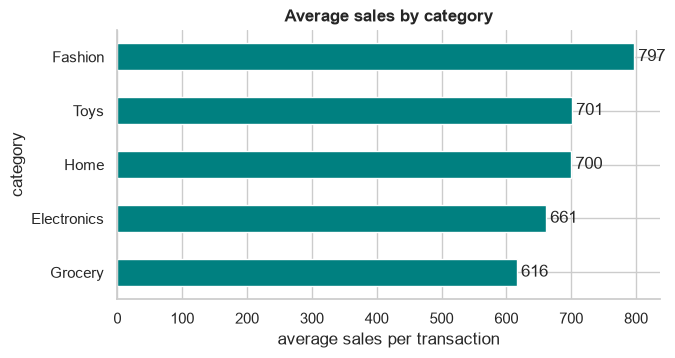

In [51]:
# Q2
avg = retail.groupby("category")["sales"].mean().sort_values()
ax = avg.plot.barh(color="teal", figsize=(7, 3.5))
ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)
ax.set_xlabel("average sales per transaction")
ax.set_title("Average sales by category")
plt.show()

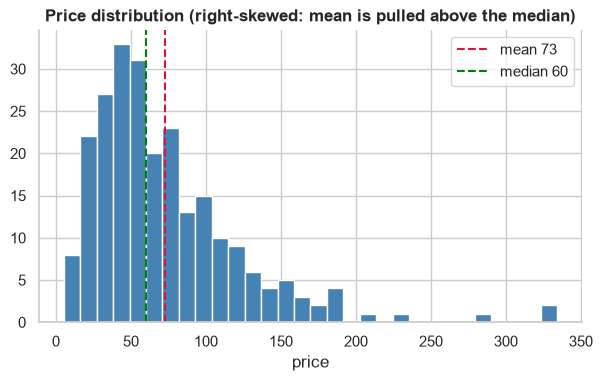

In [52]:
# Q3
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(retail["price"], bins=30, color="steelblue", edgecolor="white")
ax.axvline(retail["price"].mean(), color="crimson", linestyle="--", label=f"mean {retail['price'].mean():.0f}")
ax.axvline(retail["price"].median(), color="green", linestyle="--", label=f"median {retail['price'].median():.0f}")
ax.set_title("Price distribution (right-skewed: mean is pulled above the median)")
ax.set_xlabel("price")
ax.legend()
plt.show()

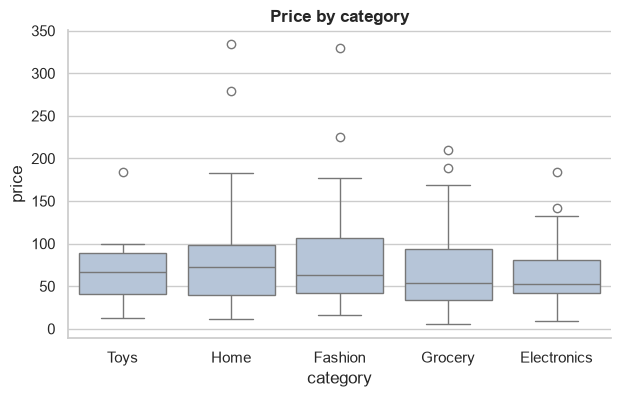

widest middle spread (IQR): Fashion 63.7


In [53]:
# Q4
sns.boxplot(data=retail, x="category", y="price", color="lightsteelblue")
plt.title("Price by category")
plt.show()

spread = retail.groupby("category")["price"].agg(lambda s: s.quantile(0.75) - s.quantile(0.25)).sort_values(ascending=False)
print("widest middle spread (IQR):", spread.index[0], round(spread.iloc[0], 1))

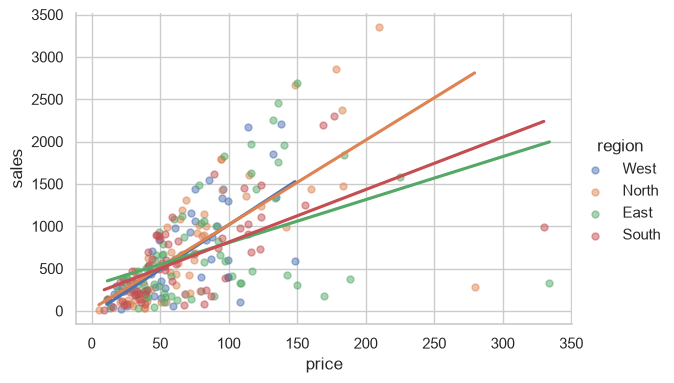

In [54]:
# Q5
sns.lmplot(data=retail, x="price", y="sales", hue="region", height=4, aspect=1.5, scatter_kws={"alpha": 0.5, "s": 25}, ci=None)
plt.show()

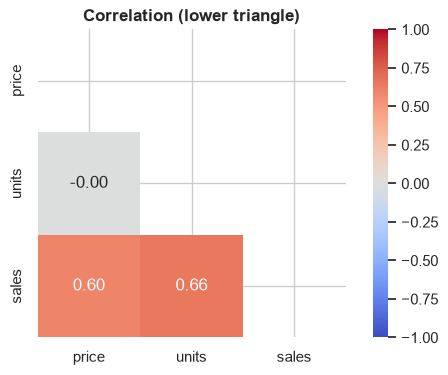

In [55]:
# Q6
c = retail[["price", "units", "sales"]].corr()
sns.heatmap(c, mask=np.triu(np.ones_like(c, dtype=bool)), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, square=True)
plt.title("Correlation (lower triangle)")
plt.show()

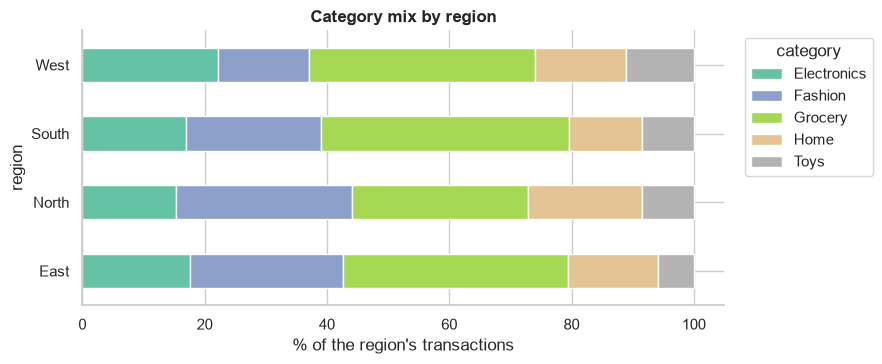

In [56]:
# Q7
share = pd.crosstab(retail["region"], retail["category"], normalize="index") * 100
ax = share.plot.barh(stacked=True, figsize=(9, 3.8), colormap="Set2")
ax.set_xlabel("% of the region's transactions")
ax.set_title("Category mix by region")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="category")
plt.tight_layout()
plt.show()

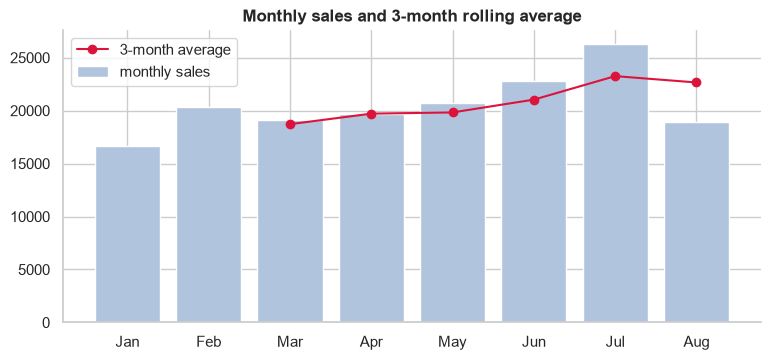

In [57]:
# Q8
monthly = retail.set_index("date")["sales"].resample("ME").sum()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(range(len(monthly)), monthly.values, color="lightsteelblue", label="monthly sales")
ax.plot(range(len(monthly)), monthly.rolling(3).mean().values, color="crimson", marker="o", label="3-month average")
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels([d.strftime("%b") for d in monthly.index])
ax.set_title("Monthly sales and 3-month rolling average")
ax.legend()
plt.show()

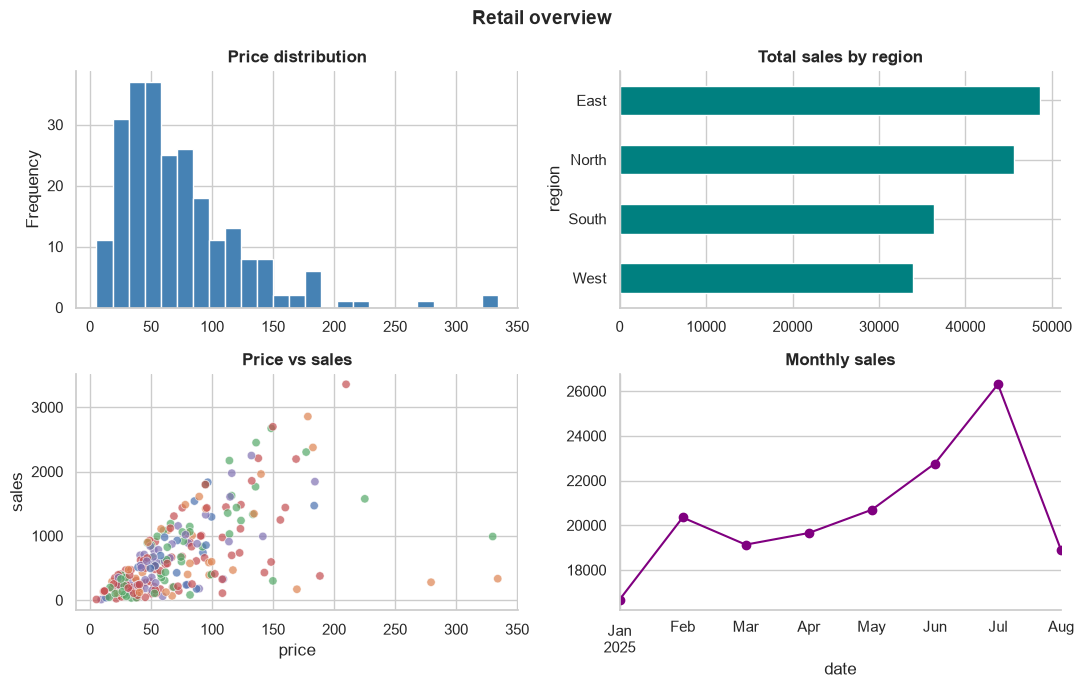

In [58]:
# Q9
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

retail["price"].plot.hist(bins=25, ax=axes[0, 0], color="steelblue", edgecolor="white", title="Price distribution")
retail.groupby("region")["sales"].sum().sort_values().plot.barh(ax=axes[0, 1], color="teal", title="Total sales by region")
sns.scatterplot(data=retail, x="price", y="sales", hue="category", ax=axes[1, 0], alpha=0.7, legend=False)
axes[1, 0].set_title("Price vs sales")
retail.set_index("date")["sales"].resample("ME").sum().plot(ax=axes[1, 1], marker="o", color="purple", title="Monthly sales")

fig.suptitle("Retail overview", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

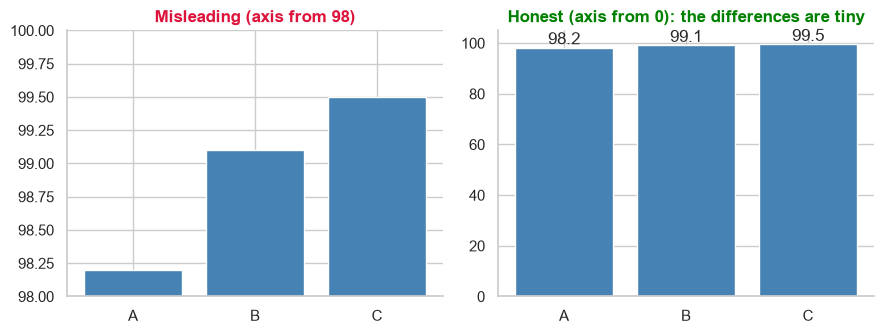

In [59]:
# Q10
values = pd.Series({"A": 98.2, "B": 99.1, "C": 99.5})

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].bar(values.index, values.values, color="steelblue")
axes[0].set_ylim(98, 100)
axes[0].set_title("Misleading (axis from 98)", color="crimson")

axes[1].bar(values.index, values.values, color="steelblue")
axes[1].set_ylim(0, 105)
axes[1].set_title("Honest (axis from 0): the differences are tiny", color="green")
axes[1].bar_label(axes[1].containers[0], fmt="%.1f")

plt.tight_layout()
plt.show()

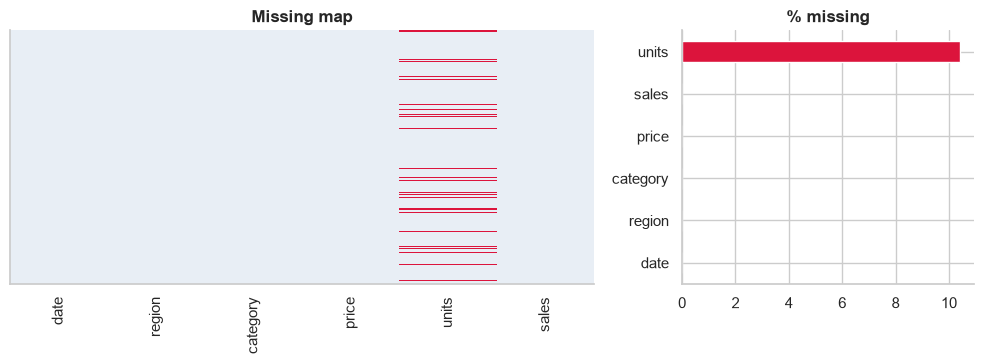

In [60]:
# Q11
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), gridspec_kw={"width_ratios": [2, 1]})
axes[0].imshow(retail.isna().to_numpy(), aspect="auto", interpolation="nearest", cmap=ListedColormap(["#e8eef5", "crimson"]))
axes[0].set_xticks(range(retail.shape[1]))
axes[0].set_xticklabels(retail.columns, rotation=90)
axes[0].set_yticks([])
axes[0].grid(False)
axes[0].set_title("Missing map")
(retail.isna().mean() * 100).sort_values().plot.barh(ax=axes[1], color="crimson", title="% missing")
plt.tight_layout()
plt.show()

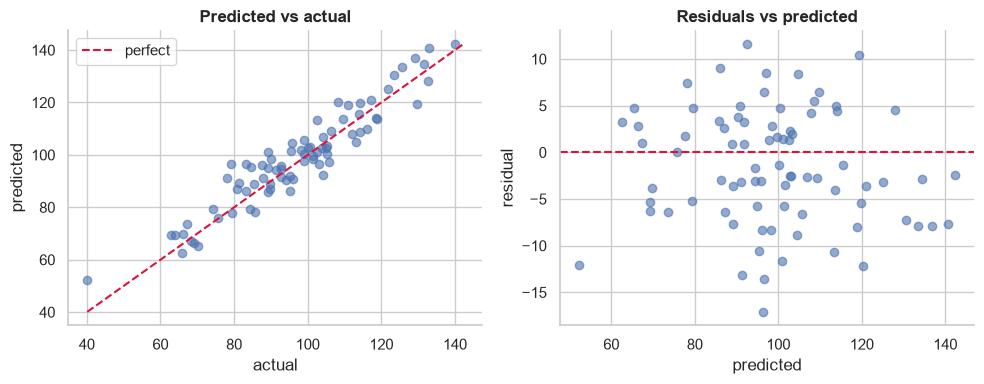

In [61]:
# Q12
resid = y_true - y_pred
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(y_true, y_pred, alpha=0.6)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
axes[0].plot(lims, lims, color="crimson", linestyle="--", label="perfect")
axes[0].set_xlabel("actual"); axes[0].set_ylabel("predicted"); axes[0].legend()
axes[0].set_title("Predicted vs actual")

axes[1].scatter(y_pred, resid, alpha=0.6)
axes[1].axhline(0, color="crimson", linestyle="--")
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("residual")
axes[1].set_title("Residuals vs predicted")

plt.tight_layout()
plt.show()

---
# 18. Cheat sheet

```python
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

# FIGURE AND AXES (object-oriented)
fig, ax = plt.subplots(figsize=(8, 4))                 fig, axes = plt.subplots(2, 2, figsize=(10, 7))
ax.set_title("...") ax.set_xlabel("...") ax.set_ylabel("...") ax.legend() ax.set_xlim(a, b) ax.set_yscale("log")
ax.axhline(y) ax.axvline(x) ax.axvspan(x1, x2) ax.annotate("txt", xy=(x, y), xytext=(x2, y2), arrowprops=dict(arrowstyle="->"))
ax.bar_label(ax.containers[0], fmt="%.0f")             ax.tick_params(axis="x", rotation=45)
fig.suptitle("...") fig.tight_layout() fig.autofmt_xdate() fig.savefig("x.png", dpi=200, bbox_inches="tight")

# PANDAS
s.plot()   s.plot.hist(bins=30)   s.plot.box()   s.plot.bar()   s.plot.barh()   s.plot.pie()
df.plot.scatter(x="a", y="b", c="c", cmap="viridis")   df.plot(subplots=True, sharex=True)
df.plot(secondary_y="col")   pd.crosstab(a, b).plot.bar(stacked=True)

# SEABORN (long data)
sns.histplot(data=df, x="a", hue="g", kde=True)        sns.ecdfplot(data=df, x="a", hue="g")
sns.boxplot(data=df, x="g", y="a")                     sns.violinplot(data=df, x="g", y="a")
sns.countplot(data=df, y="g", order=df["g"].value_counts().index)
sns.barplot(data=df, x="g", y="a", errorbar=("ci", 95))
sns.scatterplot(data=df, x="a", y="b", hue="g", size="c", alpha=0.6)
sns.regplot(data=df, x="a", y="b")                     sns.lmplot(data=df, x="a", y="b", hue="g")
sns.heatmap(df.corr(numeric_only=True), mask=np.triu(np.ones_like(c, dtype=bool)), annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0)
sns.pairplot(df, hue="g", corner=True)

# EDA CHECKLIST (plots)
missing map/bar    target distribution    each feature's histogram    correlation heatmap
feature vs target (box by class / scatter)    time series with rolling mean    category counts

# MODEL CHECKLIST (plots)
regression: predicted vs actual, residuals, coefficients       classification: confusion matrix, class balance
time series: train/test timeline, forecast vs actual vs baseline

# HONEST CHARTS
bars start at 0   sorted categories   insight in the title   labelled axes with units   colorblind palette
```

**Next chapter:** `16_project`: the final real-world AI/ML project. We will use everything from chapters 01 to 15: load and clean raw data, EDA with plots, feature engineering, a time-safe split, a baseline and a model, evaluation, and a clean, reproducible repository structure for your GitHub and interviews.